- EDA is the process of analyzing and mining data inside the dataset based on the business hypothesis with statistical proven.

In [1]:
# Import libraries which is required to analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset

df = pd.read_csv(r"C:\Users\Anshu\OneDrive\Desktop\AI Adoption & Layoff Risk Analysis\Data\Ai_Impact_jobs_Layoff_Risk_Dataset.csv")
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [3]:
# convert columns name into lowercase

df.columns = df.columns.str.lower()
df.columns.to_list()

['age',
 'education_level',
 'years_of_experience',
 'industry',
 'job_role',
 'company_size',
 'job_level',
 'routine_task_percentage',
 'creativity_requirement',
 'human_interaction_level',
 'ai_adoption_level',
 'number_of_ai_tools_used',
 'ai_usage_hours_per_week',
 'tasks_automated_percentage',
 'ai_training_hours',
 'layoff_risk']

# Phase 2: EDA ---> Exploratory Data Analysis
1. Target Variable Analysis
2. Employee Profile Analysis
3. Organization Analysis
4. Job Characteristics Analysis
5. AI Adoption Analysis
6. Multivariate Analysis
7. Key Insights

## 1. Target Variable Analysis
- Que: Why we should start from the target variable?
- --> We start with the target variable first to see if your data is balanced or not because all the analysis depends on this target variable. So first analyze the target variable data to ensure our dataset not given in biased form. If biased data present inside the dataset it makes a wrong prediction or we can say wrong analysis.

In [4]:
# counts frequency of categories 
counts = df['layoff_risk'].value_counts().reset_index(name='Count')

counts['Percentage'] = (counts['Count'] / counts['Count'].sum()*100).round(2)
counts

,layoff_risk,Count,Percentage
0,High,6797,33.98
1,Low,6602,33.01
2,Medium,6601,33.01


- The target variable looks similar across categories, the dataset not given in biased. So It's good to analyze the dataset, finding patterns and build the model.

### Categorize the variables based on their characteristic into 5 parts

In [5]:
employee_columns = ['age','education_level','years_of_experience']
organization_columns = ['industry', 'company_size']
job_characteristic_columns = ['job_role', 'job_level', 'routine_task_percentage', 'creativity_requirement', 'human_interaction_level']
ai_adoption_columns = ['ai_adoption_level', 'number_of_ai_tools_used', 'ai_usage_hours_per_week', 'tasks_automated_percentage', 'ai_training_hours']
layoff_risk_column = ['layoff_risk']

employee_profile = df[employee_columns]
organization = df[organization_columns]
job_characteristic = df[job_characteristic_columns]
ai_adoption = df[ai_adoption_columns]
target_variable = df[layoff_risk_column]


## 2. Employee Profile Analysis
    - Age
    - Education Level
    - Years of Experience
- This section answer one business question:---> Do employee characteristics influence layoff risk?

### Age

#### Univariate Analysis of Age

Q. Why this Analysis? ---> Before examining the relationship between age and layoff risk, it is important to understand the overall age distribution of the workforce. This helps identify whether the dataset represents a broad range of employees or is concentrated within a particular age group.

In [6]:
# Age is given in numerical data format so we can find its descriptive stats

print(f'Count: {np.size(df['age'])}')
print(f'Minimum: {np.min(df['age'])}')
print(f'Maximum: {np.max(df['age'])}')
print(f'Average: {np.mean(df['age'])}')
print(f'Median: {np.median(df['age'])}')
print(f'Variance: {round(np.var(df['age']),2)}')
print(f'Standard Deviation: {round(np.std(df['age']),2)}')
print(f'Quartiles[Q1-Q3]: {np.percentile(df['age'], [25, 75])}')   # Q1 ---> 25% and Q3 ---> 75%

Count: 20000
Minimum: 21
Maximum: 60
Average: 40.3615
Median: 40.0
Variance: 132.85
Standard Deviation: 11.53
Quartiles[Q1-Q3]: [30. 50.]


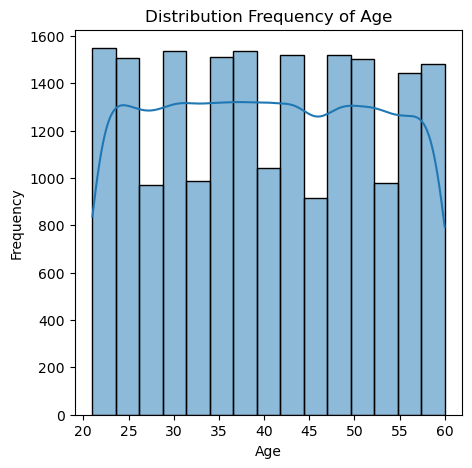

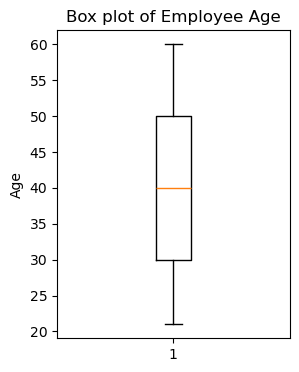

In [7]:
# Now its time to check how our data distribute --> via visually
# Analyze First: Which type of graph suitable for numerical data type?

# Histogram ---> For distribution

plt.figure(figsize=(5,5))

sns.histplot(data=df, x='age', bins=15, kde=True)
plt.title('Distribution Frequency of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Boxplot ---> For Outlier
plt.figure(figsize=(3,4))
plt.boxplot(x=df['age'])
plt.title('Box plot of Employee Age')
plt.ylabel('Age')
plt.show()

Observation:
- The average employee age is around 40 years. The dataset includes employees from different age groups, providing a good representation of the workforce. No unusual age values were identified, indicating that the age data is suitable for further analysis.

#### Bivariate Analysis: Age vs Layoff Risk
- Here we will find the relationship between the age and layoff risk.

- --->Business Que: Does employee age differ across layoff risk categories?
- ---> Business Hypothesis: Employee age may vary across layoff risk categories. Understanding this relationship can help determine whether age is associated with workforce vulnerability in an AI-driven workplace.

- Ques which is asked yourself:
##### Why this analysis?
- Age represents an employees career stage and experience. Analyzing age across layoff risk categories helps determine whether certain age groups are more represented in specific risk levels. These insights can support workforce planning, succession planning, and employee development strategies.

In [8]:
# summary of the age across the layoff risk categories
# find the descriptive stats of age and group by the layoff risk categries

summary_of_age = (df.groupby('layoff_risk')['age'].aggregate(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))
summary_of_age

,count,mean,median,std,min,max
layoff_risk,,,,,,
High,6797,39.86,40.0,11.81,21,60
Low,6602,40.90,41.0,11.34,21,60
Medium,6601,40.33,40.0,11.39,21,60


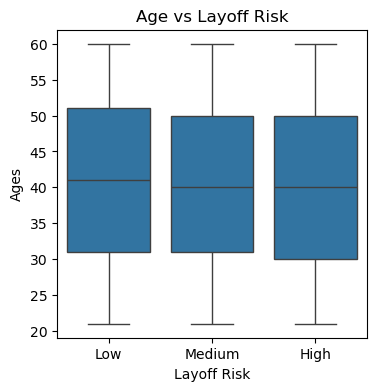

In [9]:
# creating a boxplot to visualize the data summary across target variable categories

plt.figure(figsize=(4,4))
sns.boxplot(data=df, x='layoff_risk', y='age', order=['Low', 'Medium', 'High'])
plt.title('Age vs Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('Ages')
plt.show()

Observation: 
   - The Low layoff risk category has a slightly higher median age than the Medium and High categories. However, the difference appears to be small.
   - Based on the visualization alone, there is no clear visual separation between the three layoff risk categories.
   - No significant outliers are observed in any layoff risk category, suggesting that the age distribution is consistent across groups and is not being influenced by extreme values.

#### Statistical Analysis : One-Way ANOVA test (Better for one numerical dependent variable vs three or more independent groups)

In [10]:
# import library for ANOVA test
from scipy.stats import f_oneway

# create separate groups of categorical variable with age 
low_age = df[df['layoff_risk'] == 'Low']['age']
medium_age = df[df['layoff_risk'] == 'Medium']['age']
high_age = df[df['layoff_risk'] == 'High']['age']

f_stats, p_value = f_oneway(low_age, medium_age, high_age)
print(f_stats.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('There is no statistically significant difference in the average age across the three layoff risk categories.')
else:
    print('We reject the null hypothesis')
    print('There is a statistically significant difference in the average age between at least one layoff risk category.')

13.62
1.2292684860429205e-06
We reject the null hypothesis
There is a statistically significant difference in the average age between at least one layoff risk category.


In [11]:
# Post-hoc Analysis---> Post hoc means "after this" (performed after the main ANOVA test)
# Tukey’s HSD (Honestly Significant Difference) is the specific method used to perform that post hoc analysis.

# import library which required for Tukey Test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD Test
tukey = pairwise_tukeyhsd(
    endog=df["age"],
    groups=df["layoff_risk"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low   1.0378    0.0  0.5712  1.5043   True
  High Medium    0.471 0.0472  0.0045  0.9376   True
   Low Medium  -0.5667 0.0131 -1.0367 -0.0968   True
----------------------------------------------------


In [12]:
# Eta - Squared Analysis
# Eta squared (η2) is an effect size measure used alongside ANOVA. While a p-value indicates 
    # statistical significance (whether an effect exists), Eta squared quantifies the magnitude or practical importance of that effect.

# Overall Mean
grand_mean = df["age"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["age"].count() *
    (df.groupby("layoff_risk")["age"].mean() - grand_mean) ** 2
)

# Total Sum of Squares
ss_total = sum((df["age"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.0014


##### Observation: 
- A One-Way ANOVA indicated a statistically significant difference in the average age across the three layoff risk categories (F = 13.62, p < 0.001).
-  Tukey's HSD post-hoc analysis further showed that all pairwise comparisons (Low vs Medium, Low vs High, and Medium vs High) were statistically significant.
- Despite these statistically significant differences, the effect size was negligible (η² = 0.0014), indicating that layoff risk explains only about 0.14% of the variation in employee age.

##### Business Conclusion: 
- Although average age varies slightly across layoff risk categories, the magnitude of these differences is very small. This suggests that age alone is unlikely to be a meaningful driver of layoff risk.

### Education Level

#### Univariate Analysis of Employee Education Level

- This Analysis helps to analyze how the education distribution look like?

In [13]:
# Frequency Count & Percentage Distribution
edu_summary = (df['education_level'].value_counts().reset_index(name='count'))
edu_summary['percentage(%)'] = (edu_summary['count'] / edu_summary['count'].sum()*100).round(2)
edu_summary

,education_level,count,percentage(%)
0,Bachelor's,9967,49.84
1,Master's,5426,27.13
2,High School,3558,17.79
3,PhD,1049,5.24


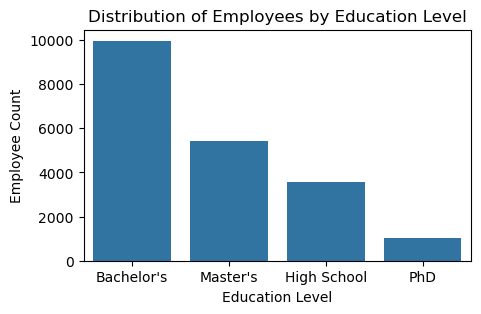

In [14]:
# Make the count plot <--> Column bar chart

plt.figure(figsize=(5,3))

sns.countplot(
    data=df,
    x="education_level",
    order=df["education_level"].value_counts().index
)

plt.title("Distribution of Employees by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Employee Count")
plt.show()

Observation
- The Bachelor's degree category has the highest number of employees in the dataset.
- The PhD category has the lowest number of employees.
- The workforce is not evenly distributed across education levels, as Bachelor's degree holders make up a substantially larger share of the employees.
- Although the PhD group is the smallest, it still contains enough observations for further analysis.

#### Bivariate Analysis: Education Level vs Layoff Risk
Que: Is layoff risk distributed differently across education levels?

In [15]:
# Contigency Table
education_layoff = pd.crosstab(df['education_level'], df['layoff_risk'])
display(education_layoff)

# percentage row level
education_layoff_percent = (pd.crosstab(df['education_level'], df['layoff_risk'], normalize='index') * 100).round(2)
display(education_layoff_percent.style.format("{:.2f}%"))

layoff_risk,High,Low,Medium
education_level,,,
Bachelor's,3494,3114,3359
High School,1621,781,1156
Master's,1471,2186,1769
PhD,211,521,317


layoff_risk,High,Low,Medium
education_level,,,
Bachelor's,35.06%,31.24%,33.70%
High School,45.56%,21.95%,32.49%
Master's,27.11%,40.29%,32.60%
PhD,20.11%,49.67%,30.22%


Observation:
- The distribution of layoff risk varies across different education levels. Employees with a High School education have the highest proportion of High layoff risk (45.56%) and the lowest proportion of Low layoff risk (21.95%).
- PhD holders have the highest proportion of Low layoff risk (49.67%) and the lowest proportion of High layoff risk (20.11%).
- Bachelor's degree holders are relatively balanced across all three layoff risk categories, while Master's degree holders show a higher concentration in the Low layoff risk category (40.29%) compared to the High layoff risk category (27.11%).
- Overall, the descriptive analysis indicates a trend where the proportion of High layoff risk decreases and the proportion of Low layoff risk increases with higher educational attainment. However, this observation is descriptive in nature and requires statistical validation to determine whether the observed association is statistically significant.

##### Statistical Analysis
Que: Why we perfom this statistical analysis?
--> We already observered the discriptive stats and find some important point, to verify that is that number we have seen really occured or by chance.

Statistical Hypothesis: Are these differences statistically significant, or could they have occurred by chance?

In [16]:
# Define Hypothesis

# H0---> There is no statistically significant association between education level and layoff risk.
# H1---> There is a statistically significant association between education level and layoff risk.

# Our both the variables are in category data type so for that we will choose the Chi-Squared Test of Independence

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(education_layoff)

print(chi2.round(2))
print(p_value)

alpha = 0.05
if p_value > alpha:
    print('Fail to reject Null Hypothesis')
    print('There is no statistically significant association between education level and layoff risk.')
else:
    print('We reject Null Hypothesis')
    print('There is a statistically significant association between education level and layoff risk.')

599.42
3.1088973146061364e-126
We reject Null Hypothesis
There is a statistically significant association between education level and layoff risk.


Observation:
- The test produced a Chi-Square statistic of 599.42 with an extremely small p-value (3.11 × 10⁻¹²⁶), which is well below the significance level of 0.05
- The null hypothesis is rejected, indicating a statistically significant association between education level and layoff risk.

---> Here chi squared gives me the proven of relationship, but our data is little big size of sample and the P_vlaue is too much smaller so any of mistaken conclusion can produce big impact of analysis. So for that we check the how strong the relationship occurs between both of them.

- So here we will use the Cramer's V Test which is equivalent to Eta Squared in the ANOVA analysis.

In [17]:
# Cramer's V Test --> Formula : sqrt(chi2/(n*min_dim))

n = education_layoff.values.sum()    # n --> Total no. of observation
min_dim = min(education_layoff.shape) - 1  # Minimum Dimension

Cramer_V = np.sqrt(chi2/(n*min_dim))

print(f'Cramer V: {Cramer_V:.4f}')

Cramer V: 0.1224


Observation:
- The value of Cramer_v is 0.12, indicates the strength of the relationship is weak. This means education has more influence than age, but it is not a dominant predictor of layoff risk.

Business Conclusion:
- The analysis indicates that education level is significantly associated with layoff risk; however, the relationship is weak in practical terms. Employees with higher educational qualifications generally exhibit a lower proportion of High layoff risk and a higher proportion of Low layoff risk. Therefore, while education level contributes to understanding layoff risk, it should not be considered a primary decision-making factor and should be evaluated alongside job-related and AI adoption variables.

### Years or Experience
Business Que: What is the distribution of employees' years of experience, and does it differ across layoff risk categories?

#### Univariate Analysis of Years of Experience

In [18]:
display(df['years_of_experience'].describe().round(2))
df['years_of_experience'].mode()[0]

count    20000.00
mean         7.27
std          4.72
min          0.00
25%          4.00
50%          7.00
75%         11.00
max         32.00
Name: years_of_experience, dtype: float64

np.int64(0)

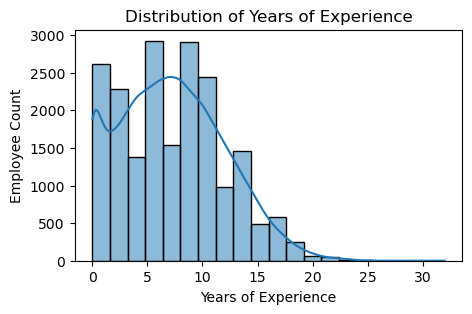

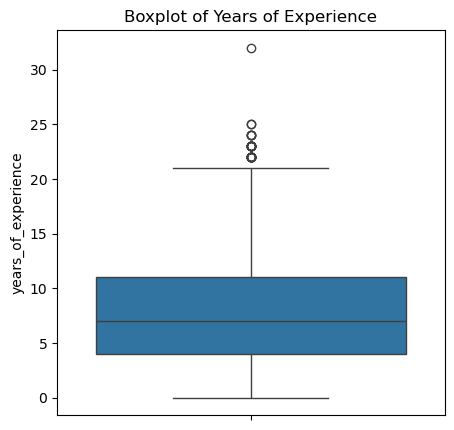

In [19]:
# Visualize the data

# Histogram

plt.figure(figsize=(5,3))
sns.histplot(data=df, x='years_of_experience', bins=20, kde=True)
plt.title('Distribution of Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Employee Count')
plt.show()

# Boxplot

plt.figure(figsize=(5,5))
sns.boxplot(y=df['years_of_experience'])
plt.title('Boxplot of Years of Experience')
plt.show()

Observation:
- The average employee has around 7 years of experience, with most employees having between 4 and 10 years of experience.
- The distribution is slightly right-skewed, indicating a small number of highly experienced employees. A few outliers (above 21 years of experience) are present, but they represent realistic workforce observations.
- Overall, the dataset captures employees across different experience levels and is suitable for further analysis.

#### Bivariate Analysis: Years of Experience vs Layoff Risk
Do employees with different levels of experience exhibit different levels of layoff risk?

---> Years of experience often reflects an employee's expertise, institutional knowledge, and role maturity. This analysis aims to determine whether employees with different experience levels are distributed differently across layoff risk categories.

In [20]:
# Descriptive Analysis based on Target Variable
summary_of_experience = (df.groupby('layoff_risk')['years_of_experience'].agg(['count', 'min', 'max', 'mean', 'median', 'std']).round(2))
print(summary_of_experience)

             count  min  max  mean  median   std
layoff_risk                                     
High          6797    0   32  6.69     6.0  4.77
Low           6602    0   24  7.85     8.0  4.68
Medium        6601    0   23  7.27     7.0  4.64


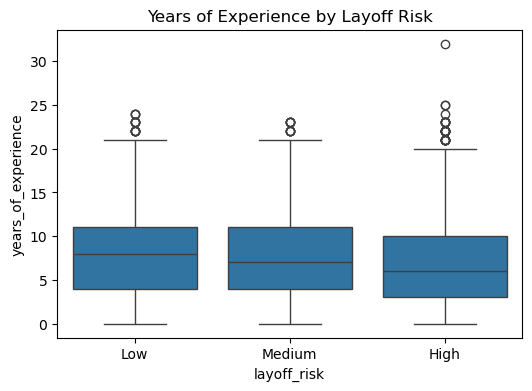

In [21]:
# Boxplot

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='layoff_risk', y='years_of_experience', order=['Low', 'Medium', 'High'])
plt.title('Years of Experience by Layoff Risk')
plt.show()

Observation:
- Employees in the Low layoff risk category tend to have slightly more work experience than those in the High layoff risk category. However, the substantial overlap between the groups suggests that years of experience alone may not be a strong differentiating factor for layoff risk. Statistical testing is required to determine whether the observed differences are statistically significant.

##### Statistical Analysis

In [22]:
# We perfoem numerical vs categorical variable so for that we will use to ANOVA test

low = df[df['layoff_risk'] == 'Low']['years_of_experience']
medium = df[df['layoff_risk'] == 'Medium']['years_of_experience']
high = df[df['layoff_risk'] == 'High']['years_of_experience']

# ANOVA TEST

# Hypothesis
# H0 = There is no significant difference in years of experience across the three layoff risk categories
# H1 = There is significance difference in years of experience across the three layoff risk categories

f_stat, p_value = f_oneway(low, medium, high)
alpha = 0.05

print(f_stat)
print(p_value)
if p_value > alpha:
    print('We fail to reject null hypothesis')
    print('There is no significance difference in years of experience across the three layoff risk categories')
else:
    print('We reject the null hypothesis')
    print('There is significance difference in years of experience across the three layoff risk categories')

102.24382426451344
6.630873660286188e-45
We reject the null hypothesis
There is significance difference in years of experience across the three layoff risk categories


In [23]:
# Tukey HSD Test --> For Analysis which factor has mostly strong

tukey = pairwise_tukeyhsd(
    endog=df["years_of_experience"],
    groups=df["layoff_risk"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low   1.1606   0.0  0.9704  1.3508   True
  High Medium   0.5713   0.0   0.381  0.7615   True
   Low Medium  -0.5893   0.0 -0.7809 -0.3977   True
---------------------------------------------------


Observation:
- The Tukey HSD post-hoc test showed statistically significant differences in years of experience between all three layoff risk categories (p < 0.001).
- Employees in the Low layoff risk category have, on average, 1.16 more years of experience than those in the High layoff risk category and 0.59 more years than those in the Medium layoff risk category.
- Employees in the Medium layoff risk category have, on average, 0.57 more years of experience than those in the High layoff risk category.

Business Perspective:
- Employees with lower layoff risk generally have more years of work experience than those with higher layoff risk.
- However, the differences in average experience are relatively small (approximately 0.6–1.2 years).
- While years of experience appears to be associated with layoff risk, its practical importance should be confirmed by evaluating the effect size.

In [24]:
# Eta-Squared Test ---> For proving how strongly the experience associate with layoff risk

# Overall Mean
grand_mean = df["years_of_experience"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["years_of_experience"].count() *
    (df.groupby("layoff_risk")["years_of_experience"].mean() - grand_mean) ** 2
)

# Total Sum of Squares
ss_total = sum((df["years_of_experience"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.0101


Observation:
- A One-Way ANOVA revealed a statistically significant difference in the average years of experience across the three layoff risk categories (F = 102.24, p < 0.001).
- Tukey's HSD test further confirmed that all pairwise comparisons were statistically significant.
- However, the effect size was small (η² = 0.0101), indicating that layoff risk explains only about 1.01% of the variation in employees' years of experience.

Business Conclusion:
- Employees with lower layoff risk generally have slightly more work experience than those with higher layoff risk. However, the practical impact of years of experience is limited, suggesting that experience alone is not a strong predictor of layoff risk. Organizations should evaluate years of experience together with job characteristics and AI-related factors to better understand layoff risk.

### Employee Profile Final Summary:
- The Employee Profile analysis indicates that all three variables(Age, Education Level, Years of Experience) show statistically significant relationships with layoff risk. However, the practical strength of these relationships is limited.
    - Age exhibits a negligible effect
    - Education Level shows a weak relationship
    - Years of Experience demonstrates a small effect size.

These findings suggest that employee demographic characteristics alone are insufficient to explain layoff risk, highlighting the importance of analyzing organizational and AI-related factors in subsequent sections.

## 3. Organization Profile Analysis
    - Industry
    - Company Size

Business Problem: ---> AI adoption is not uniform across industries. Some industries are highly automated, while others still rely heavily on human expertise. Understanding industry-wise layoff risk helps organizations identify sectors that may require workforce planning, reskilling initiatives, or AI adoption strategies.

Business Que: How are employees distributed across different industries, and is layoff risk associated with the industry in which they work?

### Industry

#### Univariate Anlaysis of Industry

In [25]:
# Frequency & Percentage table

summary_of_industry = (df['industry'].value_counts().rename_axis('Industry').reset_index(name='Employee Count'))   # here count the employees per industry category

summary_of_industry['Percentage(%)'] = (summary_of_industry['Employee Count'] / summary_of_industry['Employee Count'].sum() * 100).round(2)
summary_of_industry

,Industry,Employee Count,Percentage(%)
0,Telecom,2582,12.91
1,Healthcare,2561,12.80
2,Finance,2513,12.57
3,Logistics,2488,12.44
4,IT,2483,12.42
5,Retail,2467,12.34
6,Manufacturing,2457,12.28
7,Education,2449,12.24


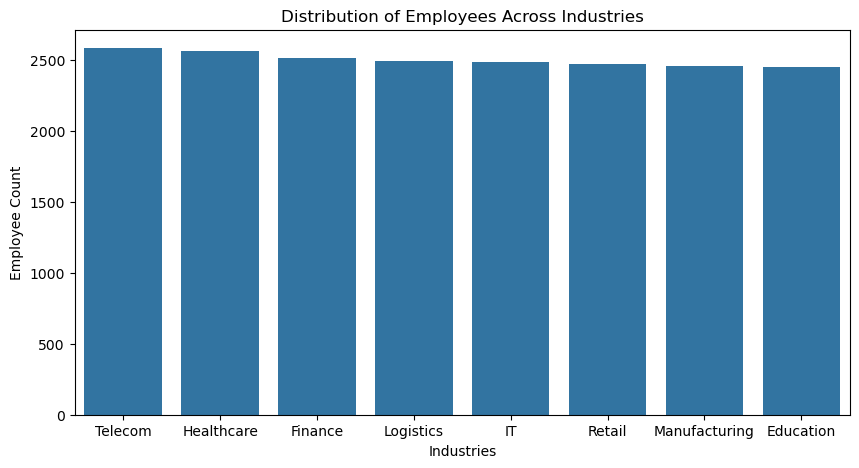

In [26]:
# create a countplot to visualize the data across industry

plt.figure(figsize=(10,5))

sns.countplot(data=df, x='industry', order=df['industry'].value_counts().index)
plt.title('Distribution of Employees Across Industries')
plt.xlabel('Industries')
plt.ylabel('Employee Count')
plt.show()

Observation:
- The dataset includes employees from eight different industries, with Telecom having the highest employee count and Education the lowest.
- The differences in employee counts across industries are minimal, indicating that the workforce is fairly evenly distributed across all industries.
- This balanced distribution reduces the likelihood of bias toward any single industry and provides a reliable basis for comparing layoff risk across sectors.

#### Bivariate Analysis: Industry vs Layoff Risk

- Here we will find this type of que: Which industries have the highest and lowest layoff risk?

In [27]:
# create a contingency table

industry_layoff = pd.crosstab(df['industry'], df['layoff_risk'])
display(industry_layoff)

industry_layoff_pct = (pd.crosstab(df["industry"], df["layoff_risk"], normalize='index') * 100).round(2)

display(industry_layoff_pct.style.format("{:.2f}%"))

layoff_risk,High,Low,Medium
industry,,,
Education,492,1186,771
Finance,948,686,879
Healthcare,532,1214,815
IT,694,948,841
Logistics,1033,622,833
Manufacturing,1185,478,794
Retail,1005,618,844
Telecom,908,850,824


layoff_risk,High,Low,Medium
industry,,,
Education,20.09%,48.43%,31.48%
Finance,37.72%,27.30%,34.98%
Healthcare,20.77%,47.40%,31.82%
IT,27.95%,38.18%,33.87%
Logistics,41.52%,25.00%,33.48%
Manufacturing,48.23%,19.45%,32.32%
Retail,40.74%,25.05%,34.21%
Telecom,35.17%,32.92%,31.91%


Observation:
- Manufacturing has the highest proportion of High layoff risk (48.23%) and the lowest proportion of Low layoff risk (19.45%) among all industries.
- Education has the highest proportion of Low layoff risk (48.43%) and the lowest proportion of High layoff risk (20.09%).
- Logistics (41.52%) and Retail (40.74%) also show relatively high proportions of employees in the High layoff risk category.
- Healthcare (47.40%) and Education (48.43%) have the largest share of employees in the Low layoff risk category.
- The Medium layoff risk category remains relatively stable across all industries, ranging from 31.21% to 34.98%.
- Overall, the descriptive analysis indicates noticeable variation in layoff risk distribution across industries, suggesting that industry may be associated with employees' layoff risk.

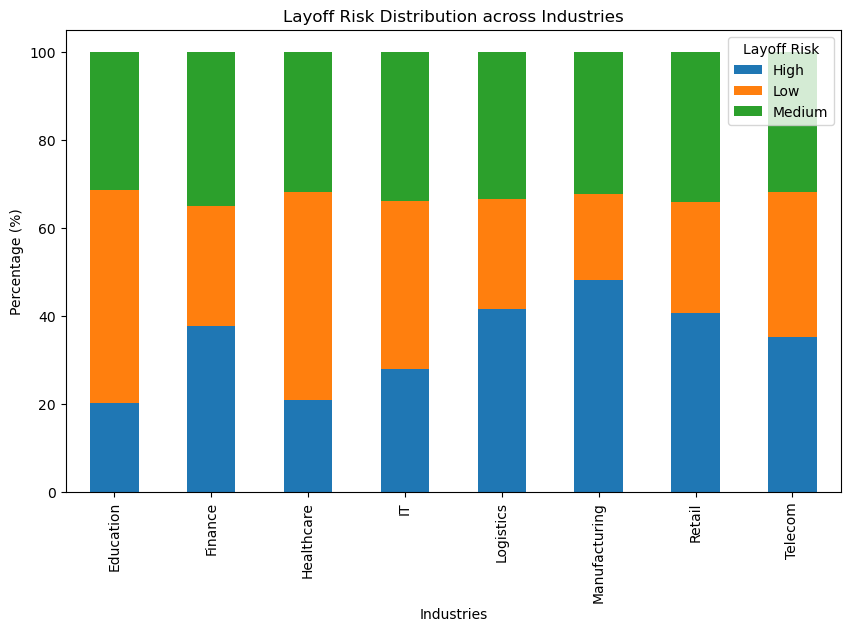

In [28]:
# visualize the data

industry_layoff_pct.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Layoff Risk Distribution across Industries')
plt.xlabel('Industries')
plt.ylabel('Percentage (%)')
plt.legend(title="Layoff Risk")
plt.show()

Observation:
- Employees working in Manufacturing, Logistics, and Retail appear to be more frequently represented in the High layoff risk category, while employees in Education and Healthcare are more commonly classified as Low layoff risk.
- This pattern suggests that industry characteristics may influence layoff risk, although statistical testing is required to confirm whether these observed differences are significant.

#### Statistical Analysis

Both the variable is in categorical data so we use Chi-Square for statistical analysis.

In [29]:
# Chi-Squared Test of Independence

chi2, p_value, dof, expected = chi2_contingency(industry_layoff)
print(chi2.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('There is no statistically significant relationship between Industry and Layoff Risk.')
else:
    print('We reject the null hypothesis')
    print('There is a statistically significant relationship between Industry and Layoff Risk')

1153.41
1.7918215338971803e-237
We reject the null hypothesis
There is a statistically significant relationship between Industry and Layoff Risk


---> Chi-Squared test gives you the relationship between present, but It does not tell us how strong that relationship is.
- so for that we will test Cramer's V test for checking the how strong the industry affects the layoff risk.

In [30]:
# Cramer's V Test

n = industry_layoff.values.sum()    # n --> Total no. of observation
min_dim = min(industry_layoff.shape) - 1  # Minimum Dimension

Cramer_V = np.sqrt(chi2/(n*min_dim))

print(f'Cramer V: {Cramer_V:.4f}')

Cramer V: 0.1698


Observation:
- The Chi-Square Test of Independence revealed a statistically significant association between Industry and Layoff Risk (χ² = 1153.41, p < 0.001).
- Cramer's V of 0.1698 indicates a weak association, suggesting that while layoff risk differs across industries, the strength of this relationship is limited.

### Company Size

#### Univariate Analysis of Company Size

In [31]:
# frequency and Percentage table

summary_of_company_size = df['company_size'].value_counts().rename_axis("Company Size").reset_index(name="Employee Count")

summary_of_company_size['Percentage(%)'] = (summary_of_company_size['Employee Count'] / summary_of_company_size['Employee Count'].sum()*100).round(2)
summary_of_company_size

,Company Size,Employee Count,Percentage(%)
0,Medium,8964,44.82
1,Small,6066,30.33
2,Large,4970,24.85


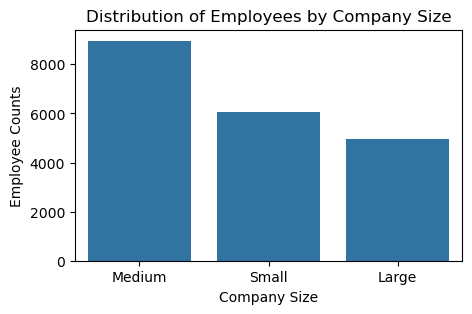

In [32]:
# Visualize the data

plt.figure(figsize=(5,3))

sns.countplot(data=df, x='company_size', order=df["company_size"].value_counts().index)
plt.title('Distribution of Employees by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Employee Counts')
plt.show()

Observation:

    - Medium: Approx(9,000)
    - Small: Approx(6,000)
    - Large: Approx(5,000)
- The dataset includes employees from Small, Medium, and Large organizations. Medium-sized companies have the highest employee representation, while Large companies have the lowest. Although the employee distribution is not perfectly balanced, all three company size categories are adequately represented, making the dataset suitable for comparing layoff risk across different organizational sizes.

#### Bivariate Analysis: Company Size vs Layoff Risk

In [33]:
# create contigency table

layoff_company_size = pd.crosstab(df['company_size'], df['layoff_risk'])
display(layoff_company_size)

layoff_company_size_pct = (pd.crosstab(df['company_size'], df['layoff_risk'], normalize='index')*100).round(2)
display(layoff_company_size_pct.style.format("{:.2f}%"))

layoff_risk,High,Low,Medium
company_size,,,
Large,1648,1692,1630
Medium,3130,2902,2932
Small,2019,2008,2039


layoff_risk,High,Low,Medium
company_size,,,
Large,33.16%,34.04%,32.80%
Medium,34.92%,32.37%,32.71%
Small,33.28%,33.10%,33.61%


Obserevation:
- The layoff risk distribution is nearly identical across Small, Medium, and Large companies, indicating no noticeable differences based on company size from the descriptive analysis.

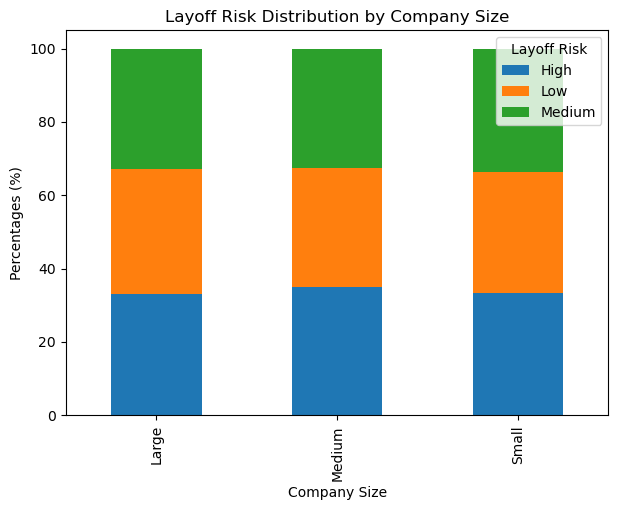

In [34]:
# create a stacked bar chart to visualize the data

layoff_company_size_pct.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title('Layoff Risk Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Percentages (%)')
plt.legend(title='Layoff Risk')
plt.show()

Observation:
- The descriptive analysis suggests that employees in Small, Medium, and Large organizations experience a very similar distribution of layoff risk. Unlike the Industry analysis, company size does not exhibit substantial variation in layoff risk, indicating that organizational scale alone may not be an important factor influencing employees' layoff risk. Statistical testing is required to confirm this observation.

#### Statistical Analysis

In [35]:
# Chi-Squared Test

chi2, p_value, dof, expected = chi2_contingency(layoff_company_size)
print(chi2.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject null hypothesis')
    print('There is no statistically significant association between company size and layoff risk')
else:
    print('We reject null hypothesis')
    print('There is a statistically significant association between company size and layoff risk')

7.88
0.09614670901055021
We fail to reject null hypothesis
There is no statistically significant association between company size and layoff risk


Observation:
- The Chi-Square test is not statistically significant, so we don't need Cramér's V to make the conclusion. Because, it doesn't change the business decision.

### Organization Profile Final Summary
- The Organization Profile analysis indicates that Industry and Company Size have different levels of association with layoff risk.
    - Industry shows a statistically significant but weak association with layoff risk (Cramér's V = 0.1386), making it the strongest organizational factor analyzed in this section.
    - Company Size shows no statistically significant association with layoff risk (p = 0.0961), suggesting that employees experience similar layoff risk regardless of organizational size.

These findings suggest that the industry in which an employee works has a greater influence on layoff risk than the size of the organization. However, industry alone does not strongly explain layoff risk, indicating that job characteristics and AI adoption factors should be further investigated to better understand the drivers of layoff risk.

## 4. Job Characteristic Analysis
    - Job Role
    - Job Level
    - Routine Task Percentage
    - Creativity Requirement
    - Human Interaction Level

#### Job Role
Business Problem: Different job roles involve different levels of routine work, creativity, decision-making, and human interaction. As AI adoption increases, some roles may be more susceptible to automation than others.

- This analysis helps identify which roles are more vulnerable and supports workforce planning and reskilling strategies.

#### Univariate Analysis of Job Role

In [36]:
# Summary of the all categories which is given in this job role

summary_of_job_role = df['job_role'].value_counts().rename_axis('Job Role').reset_index(name='Employee Count')

summary_of_job_role['Percentage(%)'] = (summary_of_job_role['Employee Count'] / summary_of_job_role['Employee Count'].sum()*100).round(2)
summary_of_job_role

,Job Role,Employee Count,Percentage(%)
0,Nurse,900,4.50
1,Medical Assistant,889,4.44
2,Financial Analyst,879,4.40
3,Support Specialist,873,4.36
4,Network Engineer,862,4.31
5,Operator,858,4.29
6,Inventory Analyst,857,4.28
7,Supply Chain Analyst,857,4.28
8,Data Analyst,849,4.24
9,Operations Analyst,847,4.23


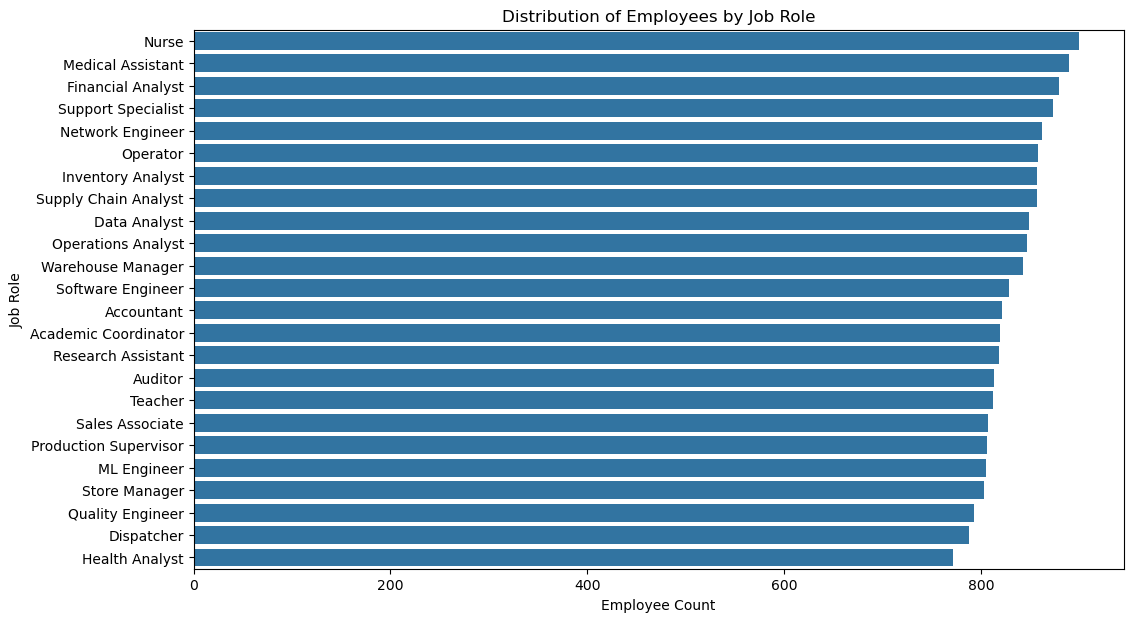

In [37]:
# visualize the data uisng the countplot 

plt.figure(figsize=(12,7))

sns.countplot(data=df, y='job_role', order=df["job_role"].value_counts().index)   #  palette="huls" is used to change colors of bars
plt.title('Distribution of Employees by Job Role')
plt.xlabel('Employee Count')
plt.ylabel('Job Role')
plt.show()

Observation:
- The dataset includes employees from a wide range of job roles representing multiple business functions and industries.
- Nurse has the highest employee representation, while Health Analyst has the lowest.
- However, the variation in employee counts across job roles is relatively small, indicating a fairly balanced distribution without any severely underrepresented roles. This balanced representation makes the dataset suitable for comparing layoff risk across different occupations.

#### Bivariate Analysis: Job Role vs Layoff Risk
Que: Does Job Role influence Layoff Risk?

In [38]:
# contingency Table

layoff_job_role = pd.crosstab(df['job_role'], df['layoff_risk'])
layoff_job_role.sort_values(by='High', ascending=False)

# Check percentages shares
layoff_job_role_perc = (pd.crosstab(df['job_role'], df['layoff_risk'], normalize='index') * 100).round(2)
layoff_job_role_perc = layoff_job_role_perc.sort_values(by='High', ascending=False)
display(layoff_job_role_perc.style.format("{:.2f}%"))

layoff_risk,High,Low,Medium
job_role,,,
Operator,50.23%,20.86%,28.90%
Production Supervisor,48.26%,18.11%,33.62%
Quality Engineer,46.03%,19.29%,34.68%
Inventory Analyst,44.57%,21.70%,33.72%
Dispatcher,42.13%,23.48%,34.39%
Warehouse Manager,41.28%,25.86%,32.86%
Supply Chain Analyst,41.19%,25.55%,33.26%
Sales Associate,40.64%,22.80%,36.56%
Accountant,39.59%,26.92%,33.50%


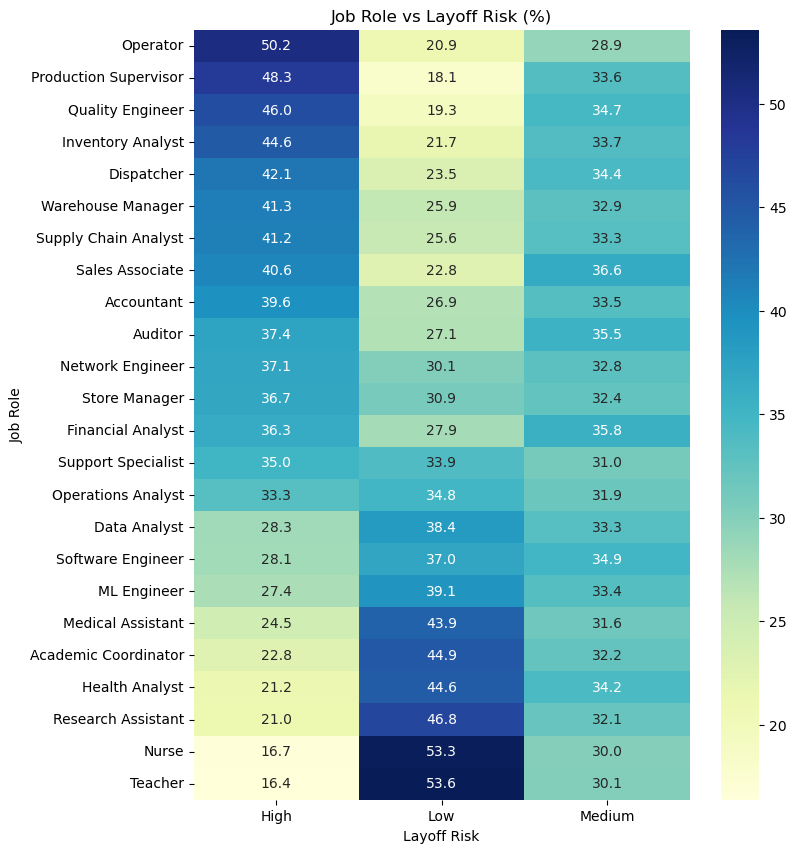

In [39]:
# Heatmap
plt.figure(figsize=(8,10))

sns.heatmap(layoff_job_role_perc, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Job Role vs Layoff Risk (%)")
plt.xlabel("Layoff Risk")
plt.ylabel("Job Role")
plt.show()

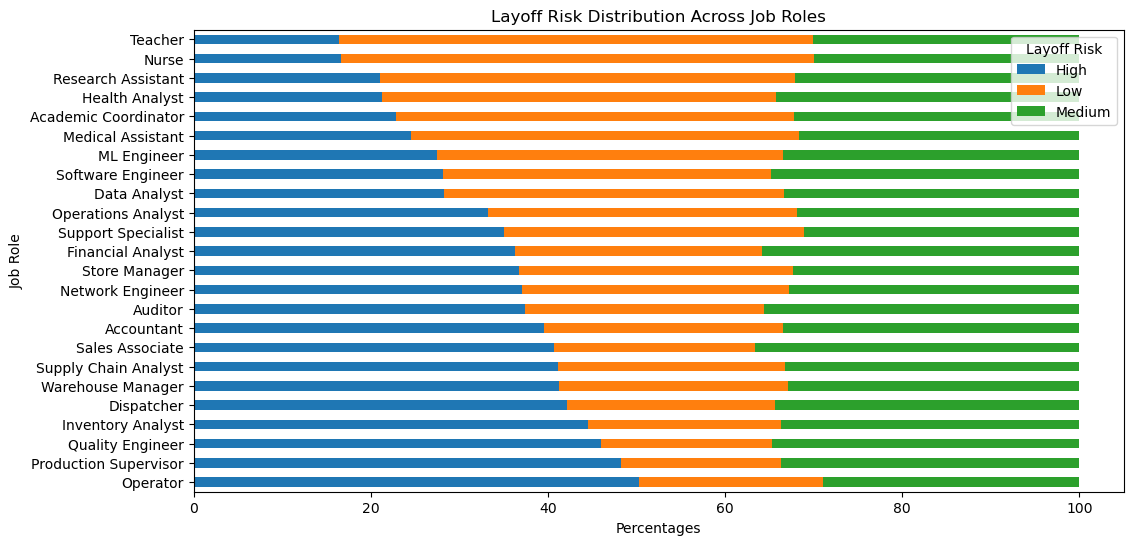

In [40]:
# stacked bar chart
layoff_job_role_perc.plot(kind='barh', stacked=True, figsize=(12,6))

plt.title('Layoff Risk Distribution Across Job Roles')
plt.xlabel('Percentages')
plt.ylabel('Job Role')
plt.legend(title='Layoff Risk')
plt.show()

Observation:
- After analysing both of the visuals, The heatmap reveals considerable variation in layoff risk across different job roles. Operational roles such as Operator, Production Supervisor, and Quality Engineer exhibit the highest proportions of High layoff risk.
- On the other hand, human-centric roles such as Teacher, Nurse, and Research Assistant show the highest proportions of Low layoff risk. These noticeable differences suggest that layoff risk is not uniformly distributed across occupations, indicating a potential association between Job Role and Layoff Risk.

#### Statistical Analysis
- For finding the potential association between Job Role and Layoff Risk are actually happen or by chance.

In [41]:
# H0 ---> There is no statistically signigicant difference between Job Role and Layoff Risk
# H1 ---> There is statistically significant difference between Job Role and Layoff Risk

# Here we will use Chi- Squared Test

chi2, P_value, dof, expected = chi2_contingency(layoff_job_role)
print(f'Chi2 Value: {chi2}')
print(f'P_Value: {P_value}')

alpha=0.05

if P_value > alpha:
    print('We fail to reject the null hypothesis')
    print('There is no statistically significant difference between Job Role and Layoff Risk')
else:
    print('We reject the null hypothesis')
    print('There is statistically significant difference between Job Role and Layoff Risk')

Chi2 Value: 1235.2156064779203
P_Value: 1.3708157204141478e-228
We reject the null hypothesis
There is statistically significant difference between Job Role and Layoff Risk


In [42]:
# Our P-value is less than 0.05, so we need to calculate the effective size 

# Cramer's V Test

n = layoff_job_role.values.sum()    # n --> Total no. of observation
min_dim = min(layoff_job_role.shape) -1   # Minimum Dimension

Cramer_V = np.sqrt(chi2/(n*min_dim))

print(f'Cramer V: {Cramer_V:.4f}')

Cramer V: 0.1757


Observation:
- The Chi-Square Test of Independence indicates a statistically significant association between Job Role and Layoff Risk (p < 0.05). Therefore, the null hypothesis is rejected.
- Cramér's V = 0.1757 indicates that the strength of this association is weak, meaning that job role contributes to explaining layoff risk but is not the sole determining factor.

### Job Level
- Organizations have employees at different hierarchical levels, such as Entry, Mid, and Senior positions. These levels differ in terms of responsibility, decision-making authority, complexity of work, and reliance on human judgment. As AI adoption increases, lower-level positions that involve more standardized and repetitive tasks may be more susceptible to automation than higher-level strategic roles.

#### Univariate Analysis of Job Level

In [43]:
# Frequency and percentage table

summary_of_job_level = df['job_level'].value_counts().reset_index(name='Count')
summary_of_job_level['Percentage(%)'] = (summary_of_job_level['Count'] / summary_of_job_level['Count'].sum() * 100).round(2)
summary_of_job_level

,job_level,Count,Percentage(%)
0,Entry,9016,45.08
1,Mid,7940,39.70
2,Senior,3044,15.22


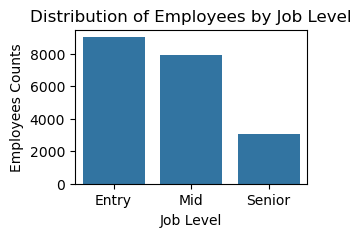

In [44]:
# visualize the data ---> Via countplot

plt.figure(figsize=(3,2))
sns.countplot(data=df, x='job_level', order=df['job_level'].value_counts().index)
plt.title('Distribution of Employees by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Employees Counts')
plt.show()

Observation
- The dataset includes employees across Entry, Mid, and Senior job levels. Entry-level employees have the highest representation, followed by Mid-level employees, while Senior-level employees have the lowest representation. Although the distribution is moderately imbalanced, each job level contains a sufficient number of observations, making the dataset appropriate for comparative analysis of layoff risk.

#### Bivariate Analysis: Job Level vs Layoff Risk

In [45]:
# Contigency & Percentage table

layoff_job_level = pd.crosstab(df['job_level'], df['layoff_risk'])
display(layoff_job_level)

layoff_job_level_perc = (pd.crosstab(df['job_level'], df['layoff_risk'], normalize='index') * 100).round(2)
display(layoff_job_level_perc.style.format("{:.2f}%"))

layoff_risk,High,Low,Medium
job_level,,,
Entry,4013,2052,2951
Mid,2435,2793,2712
Senior,349,1757,938


layoff_risk,High,Low,Medium
job_level,,,
Entry,44.51%,22.76%,32.73%
Mid,30.67%,35.18%,34.16%
Senior,11.47%,57.72%,30.81%


Observation:
- The distribution of layoff risk varies substantially across job levels.
    - Entry-level employees exhibit the highest proportion of High layoff risk (44.51%).
    - Senior-level employees have the highest proportion of Low layoff risk (57.72%).
    - Mid-level employees display a more balanced distribution across all three layoff risk categories.
- These differences suggest that layoff risk is not uniformly distributed across organizational levels, indicating a potential association between Job Level and Layoff Risk.

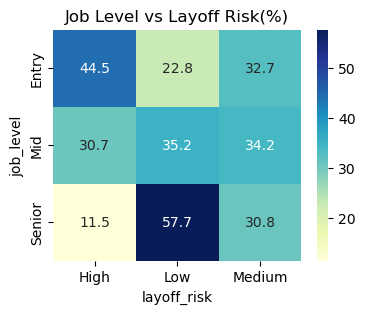

In [46]:
# visualize the data ---> via heatmap

# Heatmap

plt.figure(figsize=(4,3))
sns.heatmap(layoff_job_level_perc, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Job Level vs Layoff Risk(%)')
plt.show()


Observation:
- The analysis shows a clear variation in layoff risk across job levels.
    - Entry-level employees have the highest proportion of High layoff risk (44.5%).
    - Senior-level employees have the highest proportion of Low layoff risk (57.7%).
    - Mid-level employees exhibit a relatively balanced distribution across all risk categories.
- This suggests that lower-level positions, which often involve more routine tasks, are more vulnerable to AI-driven layoffs, whereas senior roles requiring leadership and strategic decision-making appear more resilient.

#### Statistical Analysis
Our Both the attributes have contain category variables so we use Chi2 test to check is there any difference is available or not?

In [47]:
# Chi2 Squared Test

chi2, p_value, dof, expected = chi2_contingency(layoff_job_level)
print(chi2.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We Fail to reject null hypothesis')
    print('There is no statistically significant association between Job Level and Layoff Risk')
else:
    print('We reject the null hypothesis')
    print('There is a statistically significant association between Job Level and Layoff Risk')

1642.96
0.0
We reject the null hypothesis
There is a statistically significant association between Job Level and Layoff Risk


Observation:
- The Chi-Square test confirms that these differences are not due to random chance.
    - Entry --> 44.5% High Risk
    - Mid --> 30.7% High Risk
    - Senior --> 11.5% High Risk

In [48]:
# Cramer's V

n = layoff_job_level.values.sum()
min_dimension = min(layoff_job_level.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dimension))

print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.2027


Observation: 
- The Chi-Square Test of Independence revealed a statistically significant association between Job Level and Layoff Risk (χ² = 1642.96, p < 0.001
- Cramér's V = 0.2027 indicates a weak association, suggesting that job level influences layoff risk, although the overall practical effect remains limited.

Business Conclusion:
- The analysis confirms that Job Level is significantly associated with Layoff Risk and currently represents the strongest predictor among all employee and organizational characteristics analyzed so far. However, despite being the strongest variable to date, the weak effect size indicates that job level alone cannot fully explain layoff risk. Additional job characteristics and AI adoption variables should be examined to gain a more comprehensive understanding of the factors influencing AI-driven layoffs.

### Routine Task Percentage
A routine task is a task performed in the same way every time with minimal human judgment.
- Routine Task Percentage = (Total working time / Time spent on routine tasks) ​×100

- Routine Task Percentage represents the proportion of an employee's work that consists of repetitive, rule-based, and standardized activities that can potentially be automated using AI or software. Employees with higher routine task percentages are expected to face greater automation exposure and, consequently, a higher risk of AI-related layoffs.

#### Univariate Analysis of Routine Task Percentage

In [49]:
# summary of routine task
summary_of_routine_task = df['routine_task_percentage'].describe().round(2)
summary_of_routine_task

count    20000.00
mean        51.89
std         24.44
min         10.00
25%         31.00
50%         52.00
75%         73.00
max         94.00
Name: routine_task_percentage, dtype: float64

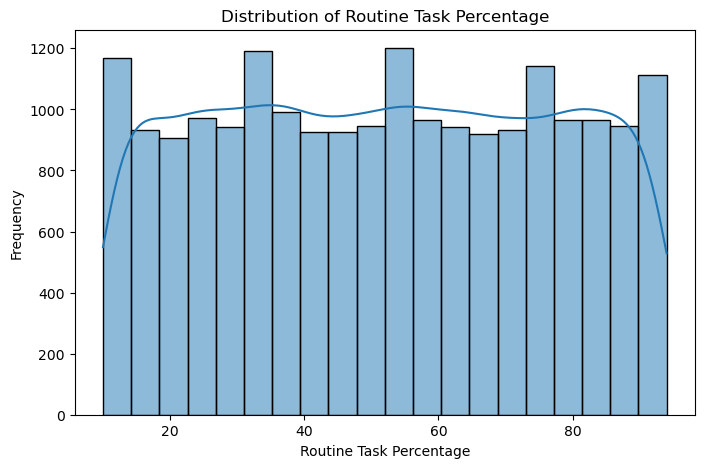

In [50]:
# Histogram

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="routine_task_percentage", bins=20, kde=True)
plt.title("Distribution of Routine Task Percentage")
plt.xlabel("Routine Task Percentage")
plt.ylabel("Frequency")
plt.show()

Observation:
- The Routine Task Percentage is fairly evenly distributed across the range of 10% to 94%, with no significant skewness or unusual peaks. This indicates a well-balanced dataset representing employees with varying levels of routine work.

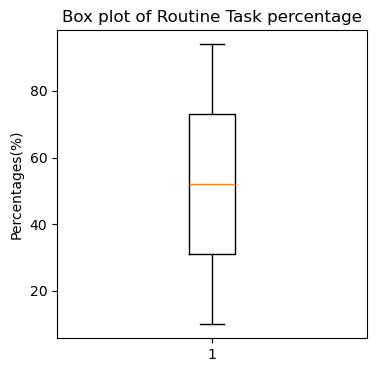

In [51]:
# boxplot

plt.figure(figsize=(4,4))
plt.boxplot(df['routine_task_percentage'])
plt.title('Box plot of Routine Task percentage')
plt.ylabel('Percentages(%)')
plt.show()

Observation:
- The Routine Task Percentage ranges from 10% to 94%, with an average of 51.9% and a median of 52%, indicating that employees spend about half of their work on routine tasks. The distribution is fairly balanced with no visible outliers, suggesting good variability for further analysis.

#### Bivariate Analysis: Routine Task Percentage vs Layoff Risk

In [52]:
# Group wize analysis

layoff_routine_task = df.groupby('layoff_risk')['routine_task_percentage'].describe().round(2)
layoff_routine_task

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,75.17,13.41,24.0,66.0,77.0,86.0,94.0
Low,6602.0,28.54,14.36,10.0,17.0,26.0,37.0,93.0
Medium,6601.0,51.26,17.72,10.0,38.0,50.0,64.0,94.0


Observation:
- The average Routine Task Percentage increases consistently across layoff risk categories: Low (28.5%), Medium (51.3%), and High (75.2%). The median follows the same trend (26% → 50% → 77%), indicating a strong positive relationship between routine work and layoff risk.

#### Statistical Analysis

In [53]:
# ANOVA Test

low = df[df['layoff_risk'] == 'Low']['routine_task_percentage']
medium = df[df['layoff_risk'] == 'Medium']['routine_task_percentage']
high = df[df['layoff_risk'] == 'High']['routine_task_percentage']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('There is no statistically significant difference in the mean Routine Task Percentage across Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('There is a statistically significant difference in the mean Routine Task Percentage across Layoff Risk categories')

15645.38
0.0
We reject the null hypothesis
There is a statistically significant difference in the mean Routine Task Percentage across Layoff Risk categories


In [54]:
# Tukey HSD Test --> For analysing which group mean different

tukey = pairwise_tukeyhsd(
    endog=df['routine_task_percentage'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  High    Low -46.6327   0.0 -47.2508 -46.0147   True
  High Medium -23.9173   0.0 -24.5354 -23.2992   True
   Low Medium  22.7154   0.0  22.0929   23.338   True
-----------------------------------------------------


Observation:
- The Tukey HSD test shows that all pairwise comparisons are statistically significant (adjusted p < 0.001).
- The average Routine Task Percentage differs significantly between High and Low (46.63%), High and Medium (23.92%), and Low and Medium (22.72%) layoff risk groups.
- The significant differences across all three groups indicate that as the proportion of routine work increases, the likelihood of AI-related layoff risk also increases.

In [55]:
# Eta-Squared Test ---> For proving how strongly the routine task percentage associate with layoff risk

# Overall Mean
grand_mean = df["routine_task_percentage"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["routine_task_percentage"].count() *
    (df.groupby("layoff_risk")["routine_task_percentage"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["routine_task_percentage"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.6101


Observation:
- The effect size (η² = 0.6101) indicates a very large practical association, meaning that approximately 61.0% of the variation in Routine Task Percentage is associated with differences among the layoff risk groups. This suggests that Routine Task Percentage is one of the strongest factors related to layoff risk in the dataset.

Business prospective:
- Employees with a higher proportion of routine, repetitive work are substantially more likely to belong to higher layoff risk categories. This highlights routine work as a key business characteristic associated with AI-driven workforce vulnerability and suggests that roles dominated by repetitive tasks may benefit most from reskilling or job redesign initiatives.

### Creativity Requirement
- It measures how much a job depends on human creativity rather than following fixed rules or repetitive processes.
- Jobs with a higher creativity requirement are generally more resistant to AI-driven automation because they rely on human innovation, judgment, and original thinking. In contrast, jobs requiring little creativity are more likely to be automated and therefore may face a higher layoff risk.

#### Univariate Analysis of creativity requirement

In [56]:
# find the descriptive stats

summary_of_creativity = df['creativity_requirement'].describe().round(2)
summary_of_creativity

count    20000.00
mean        47.79
std         26.10
min          0.00
25%         27.00
50%         48.00
75%         69.00
max        100.00
Name: creativity_requirement, dtype: float64

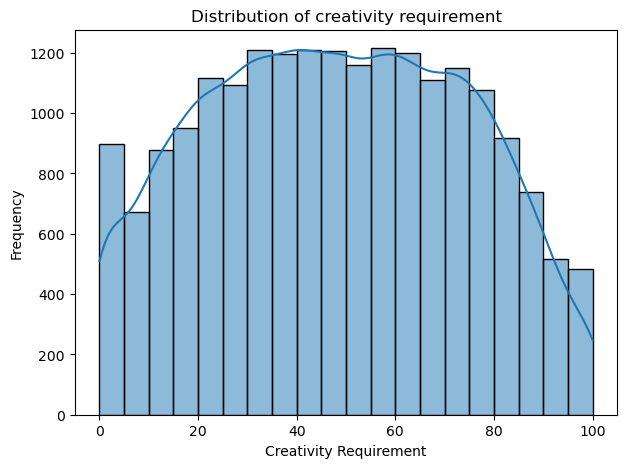

In [57]:
# visualize using histplot

plt.figure(figsize=(7,5))
sns.histplot(data=df, x='creativity_requirement', bins=20, kde=True)
plt.title('Distribution of creativity requirement')
plt.xlabel('Creativity Requirement')
plt.ylabel('Frequency')
plt.show()

Observation:
- The Creativity Requirement ranges from 0 to 100, with a mean of 47.8 and a median of 48, indicating that employees generally require a moderate level of creativity.
- The histogram shows a fairly even distribution across the range rather than a bell-shaped curve, suggesting that the variable is not normally distributed.

#### Bivariate Analysis: Creativity Requirement vs Layoff Risk

In [58]:
layoff_creativity = df.groupby('layoff_risk')['creativity_requirement'].describe().round(2)
layoff_creativity

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,23.84,15.57,0.0,12.0,22.0,35.0,83.0
Low,6602.0,71.93,16.64,4.0,61.0,74.0,84.0,100.0
Medium,6601.0,48.30,19.08,0.0,35.0,49.0,62.0,100.0


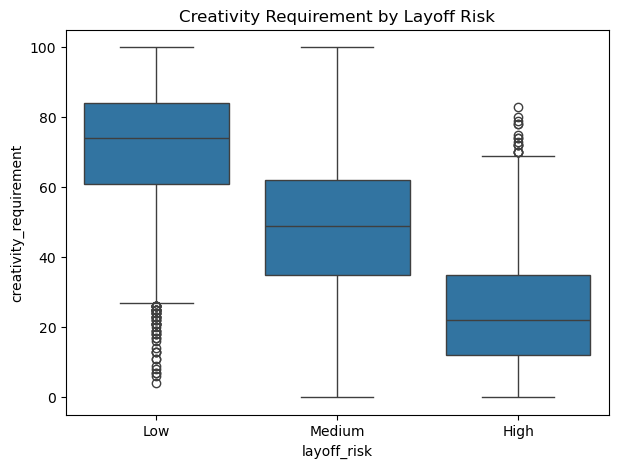

In [59]:
# boxplot

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='layoff_risk', y='creativity_requirement', order=['Low', 'Medium', 'High'])
plt.title('Creativity Requirement by Layoff Risk')
plt.show()

Observation:
- The average Creativity Requirement decreases consistently across layoff risk categories:
    - Low (71.9), Medium (48.3), and High (23.8).
    - The median also follows the same pattern (74 --> 49 --> 22), indicating a strong negative relationship between creativity requirement and layoff risk. Although there is some overlap and a few outliers, the three groups are clearly separated.
- Employees in roles requiring higher creativity are predominantly associated with the Low layoff risk category, whereas employees in less creative roles are more likely to fall into the High layoff risk category. This suggests that creative and innovative work is less susceptible to AI-driven automation than routine, rule-based work.

#### Statistical Analysis

In [60]:
# ANOVA Test ---> Finding the relationship between creativity requirement vs layoff mean difference occurs or by chance

low = df[df['layoff_risk'] == 'Low']['creativity_requirement']
medium = df[df['layoff_risk'] == 'Medium']['creativity_requirement']
high = df[df['layoff_risk'] == 'High']['creativity_requirement']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('The mean Creativity Requirement is the same across all Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean Creativity Requirement')

13173.14
0.0
We reject the null hypothesis
At least one Layoff Risk category has a different mean Creativity Requirement


In [61]:
# Tukey HSD Test --> For analysing which group mean different

tukey = pairwise_tukeyhsd(
    endog=df['creativity_requirement'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  High    Low  48.0825   0.0  47.3881  48.7769   True
  High Medium  24.4518   0.0  23.7574  25.1463   True
   Low Medium -23.6307   0.0 -24.3302 -22.9312   True
-----------------------------------------------------


Observation:
- The Tukey HSD test shows that all pairwise comparisons are statistically significant (adjusted p < 0.001). The largest difference in Creativity Requirement is observed between the High and Low layoff risk groups (48.08 points), followed by High vs Medium (24.45 points) and Low vs Medium (23.63 points).

In [62]:
# Eta-Squared Test ---> For proving how strongly the routine task percentage associate with layoff risk

# Overall Mean
grand_mean = df["creativity_requirement"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["creativity_requirement"].count() *
    (df.groupby("layoff_risk")["creativity_requirement"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["creativity_requirement"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.5685


Observation:
- The effect size (η² = 0.5685) indicates a very large practical effect, suggesting that approximately 56.9% of the variation in Creativity Requirement is associated with differences among the layoff risk groups.
- The findings indicate that creativity is a major factor associated with AI-related layoff risk. Employees in roles requiring higher creativity are significantly more likely to belong to the Low layoff risk category, while employees in less creative roles are more likely to fall into the High layoff risk category. The very large effect size highlights that creativity requirement is one of the strongest job characteristics associated with AI-driven workforce vulnerability.

Conclusion:
- The analysis confirms that Creativity Requirement has a strong and statistically significant association with layoff risk. Along with Routine Task Percentage, it emerges as one of the most influential job characteristics in the dataset, suggesting that jobs requiring innovation, critical thinking, and creative problem-solving are considerably more resilient to AI-driven automation than routine, rule-based roles.

### Human Interaction level
- Human Interaction Level refers to measures how much a job depends on interacting with people rather than working independently or following automated processes.

#### Univariate Analysis of human interaction level

In [63]:
# find the descriptive analysis of this category

summary_of_human_interaction = df['human_interaction_level'].describe().round(2)
summary_of_human_interaction

count    20000.00
mean        60.06
std         22.27
min         20.00
25%         41.00
50%         62.00
75%         79.00
max         99.00
Name: human_interaction_level, dtype: float64

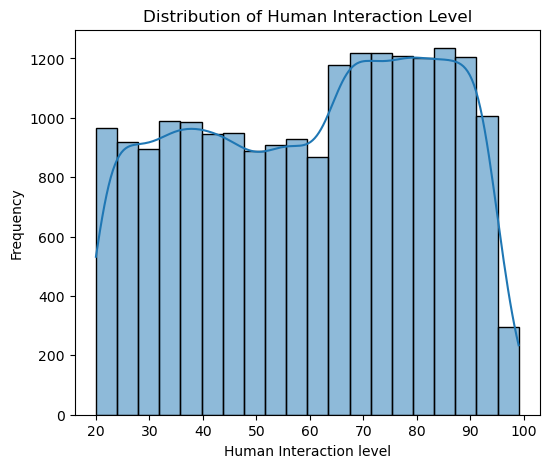

In [64]:
# histplot --> to visualize the data
plt.figure(figsize=(6,5))
sns.histplot(data=df, x='human_interaction_level', bins=20, kde=True)
plt.title('Distribution of Human Interaction Level')
plt.xlabel('Human Interaction level')
plt.ylabel('Frequency')
plt.show()

Observation:
- Human Interaction Level ranges from 20 to 99, with an average of 60.1 and a median of 62. The histogram is not normally distributed and shows a slight left-skew, with a higher concentration of employees having moderate to high levels of human interaction.

#### Bivariate Analysis: Human Interaction Level vs Layoff Risk

In [65]:
# check the descriptive stats via layoff risk
layoff_human_interaction = df.groupby('layoff_risk')['human_interaction_level'].describe().round(2)
display(layoff_human_interaction)

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,55.92,22.12,20.0,36.0,56.0,75.0,99.0
Low,6602.0,64.63,21.60,20.0,47.0,69.0,83.0,99.0
Medium,6601.0,59.73,22.22,20.0,40.0,62.0,79.0,99.0


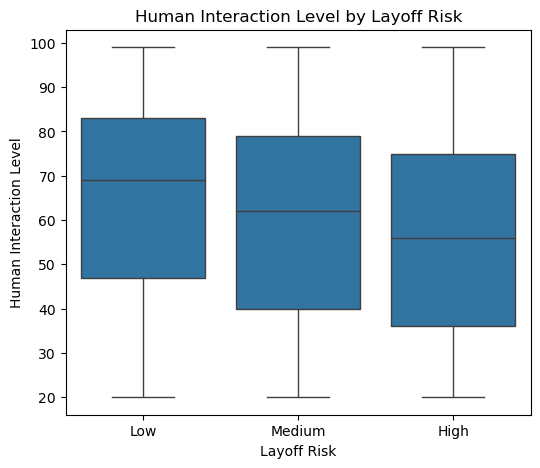

In [66]:
# visualize the data using boxplot

plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='layoff_risk', y='human_interaction_level', order=['Low', 'Medium', 'High'])
plt.title('Human Interaction Level by Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('Human Interaction Level')
plt.show()

Observation:
- The average Human Interaction Level decreases across layoff risk categories: Low (64.6), Medium (59.7), and High (55.9). The median follows the same pattern (69 --> 62 --> 56), indicating a gradual decline in human interaction as layoff risk increases. However, there is considerable overlap between the three groups, suggesting a weaker relationship compared to Routine Task Percentage and Creativity Requirement.

#### Statistical Analysis


In [67]:
# ANOVA Test

low = df[df['layoff_risk'] == 'Low']['human_interaction_level']
medium = df[df['layoff_risk'] == 'Medium']['human_interaction_level']
high = df[df['layoff_risk'] == 'High']['human_interaction_level']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('E fail to reject the null hypothesis')
    print('The mean Human Interaction Level is the same across all Layoff Risk categories')
else:
    print('we reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean Human Interaction Level')

263.6
1.0037753365653694e-113
we reject the null hypothesis
At least one Layoff Risk category has a different mean Human Interaction Level


Observation:
- At a significance level of α = 0.05, the p-value (1.00 × 10⁻¹¹³) is much smaller than 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in the mean Human Interaction Level across the three Layoff Risk categories.

In [68]:
# Tukey HSD Test --> for finding where the mean difference is not equal

tukey = pairwise_tukeyhsd(
    endog=df['human_interaction_level'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low   8.7039   0.0  7.8136  9.5942   True
  High Medium   3.8104   0.0    2.92  4.7007   True
   Low Medium  -4.8936   0.0 -5.7903 -3.9968   True
---------------------------------------------------


Observation:
- Employees in the Low layoff risk category require significantly higher levels of human interaction than those in the Medium and High risk categories. However, the differences between the groups are considerably smaller than those observed for Routine Task Percentage and Creativity Requirement, suggesting that Human Interaction Level has a weaker association with AI-related layoff risk.

In [69]:
# Eta Squared Test

# Overall Mean
grand_mean = df["creativity_requirement"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["human_interaction_level"].count() *
    (df.groupby("layoff_risk")["human_interaction_level"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["human_interaction_level"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.2526


Observation:
- The effect size (η² = 0.2526) indicates a large practical effect, suggesting that approximately 25.26% of the variation in Human Interaction Level is associated with differences among the layoff risk groups.

Conclusion:
- The analysis confirms that Human Interaction Level has a statistically significant and practically meaningful association with layoff risk. However, compared with other job characteristics, routine work and creativity requirement remain the strongest factors associated with AI-driven workforce vulnerability.

## 5. Ai Adoption Analysis
    - Ai Adoption Level
    - Numbers of Ai Tools Used
    - Ai Usage Hours per Week
    - Tasks Automated Percentage
    - Ai Training Hours

### Ai Adoption Level
- It measures how much AI is being used in a job or organization to assist or automate work.

#### Univariate Analysis of Ai Adoption Level

In [70]:
# Frequency Count and Percentage

summary_of_ai_adoption = (df['ai_adoption_level'].value_counts().reset_index(name='Count'))
summary_of_ai_adoption['Percentage(%)'] = (summary_of_ai_adoption['Count'] / summary_of_ai_adoption['Count'].sum() * 100).round(2)
summary_of_ai_adoption

,ai_adoption_level,Count,Percentage(%)
0,Low,10539,52.70
1,Medium,8046,40.23
2,High,1415,7.07


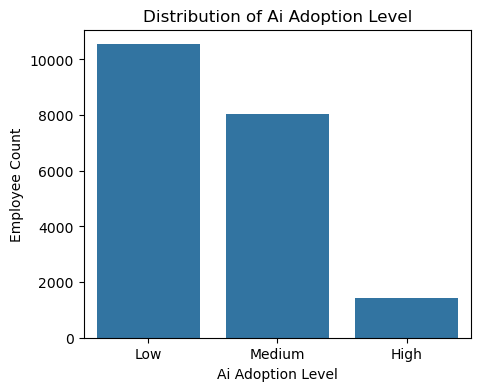

In [71]:
# visualize the data via using countplot

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='ai_adoption_level', order=['Low', 'Medium', 'High'])
plt.title('Distribution of Ai Adoption Level')
plt.xlabel('Ai Adoption Level')
plt.ylabel('Employee Count')
plt.show()

Observation:
- The dataset is dominated by employees with a Low AI Adoption Level (52.7%), followed by Medium (40.2%), while only 7.1% of employees fall into the High AI Adoption category. This indicates an imbalanced distribution, with high AI adoption being relatively uncommon in the dataset.
- The findings suggest that AI adoption is still at an early stage for most employees, with more than half working in low AI adoption environments. The relatively small proportion of employees with high AI adoption provides an opportunity to examine whether greater AI integration is associated with changes in layoff risk.

#### Bivariate Analysis: Ai Adoption Level vs Layoff Risk

In [72]:
# Contingency Table and Percentages

layoff_ai_adoption_level = pd.crosstab(df['layoff_risk'], df['ai_adoption_level'])
display(layoff_ai_adoption_level)

layoff_ai_adoption_level_perc = (pd.crosstab(df['layoff_risk'], df['ai_adoption_level'], normalize='index') * 100).round(2)
display(layoff_ai_adoption_level_perc.style.format("{:.2f}%"))

ai_adoption_level,High,Low,Medium
layoff_risk,,,
High,1143,974,4680
Low,17,5919,666
Medium,255,3646,2700


ai_adoption_level,High,Low,Medium
layoff_risk,,,
High,16.82%,14.33%,68.85%
Low,0.26%,89.65%,10.09%
Medium,3.86%,55.23%,40.90%


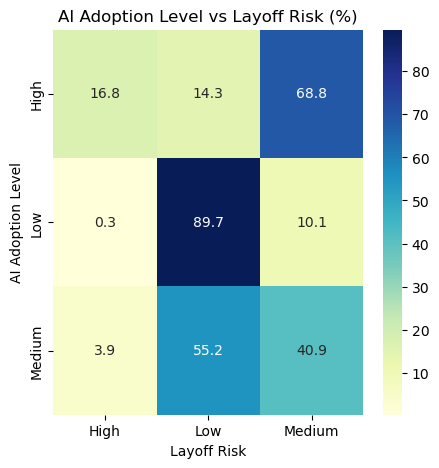

In [73]:
# heatmap

plt.figure(figsize=(5,5))
sns.heatmap(layoff_ai_adoption_level_perc, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('AI Adoption Level vs Layoff Risk (%)')
plt.xlabel('Layoff Risk')
plt.ylabel('AI Adoption Level')
plt.show()

Observation:
- The distribution of layoff risk varies considerably across AI Adoption Levels. Employees with Low AI Adoption are predominantly classified as Low layoff risk (89.7%), whereas employees with High AI Adoption are primarily classified as Medium (68.9%) and High (16.8%) layoff risk. This pattern suggests a strong association between AI Adoption Level and Layoff Risk.
- The findings indicate that higher AI adoption is associated with a shift toward higher layoff risk categories.

#### Statistical Analysis

In [74]:
# Chi2 test

chi2, p_value, dof, expected = chi2_contingency(layoff_ai_adoption_level)
print(chi2.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('There is no statistically significant association between AI Adoption Level and Layoff Risk')
else:
    print('We reject the null hypothesis')
    print('There is a statistically significant association between AI Adoption Level and Layoff Risk')

7935.67
0.0
We reject the null hypothesis
There is a statistically significant association between AI Adoption Level and Layoff Risk


Observation:
- The Chi-Square test confirms a statistically significant association between AI Adoption Level and Layoff Risk (χ² = 7935.67, p < 0.001). This indicates that the distribution of layoff risk differs significantly across the three AI adoption levels.
- The findings suggest that AI adoption level is strongly associated with employees' layoff risk. Employees working in high AI adoption environments are more frequently classified into medium and high layoff risk categories, whereas employees in low AI adoption environments are predominantly classified as low layoff risk.

In [75]:
# Cramer's V test ---> for finding the Effective Size

n = layoff_ai_adoption_level.values.sum()

min_dimension = min(layoff_ai_adoption_level.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dimension))

print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.4454


Observation:
- Cramér's V = 0.4454 indicates 44.54% a strong association, suggesting that AI Adoption Level is strongly associated with employees' layoff risk.
- The analysis confirms that AI Adoption Level has a statistically significant and strong association with layoff risk. Among all the categorical variables analyzed, AI Adoption Level emerges as the most influential factor, highlighting that the extent of AI integration within the workplace is strongly associated with employees' layoff risk.

### Numbers of Ai Tools Used
- It measures how many AI-powered tools an employee actively uses to complete their tasks.

#### Univariate Analysis of Numbers of Ai tools used

In [76]:
# descriptve Analysis

summary_of_ai_tools_used = df['number_of_ai_tools_used'].describe().round(2)
summary_of_ai_tools_used

count    20000.00
mean         2.46
std          2.10
min          0.00
25%          1.00
50%          2.00
75%          4.00
max         10.00
Name: number_of_ai_tools_used, dtype: float64

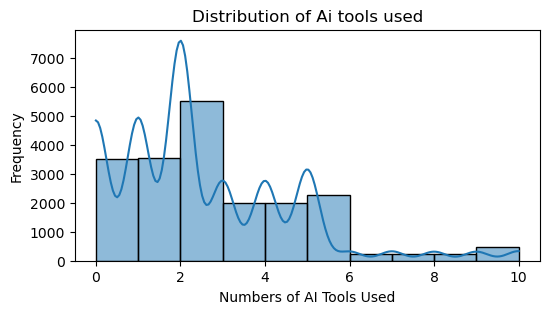

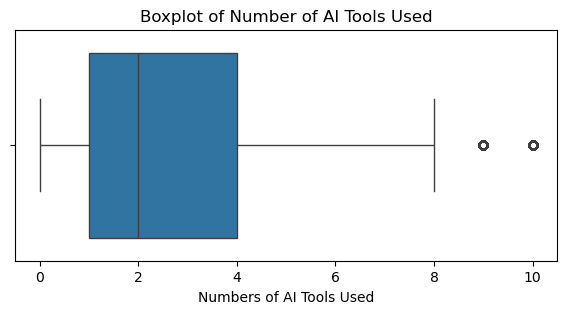

In [77]:
# Histplot and Boxplot---> To visualize the data

plt.figure(figsize=(6,3))
sns.histplot(data=df, x='number_of_ai_tools_used', bins=10, kde=True)
plt.title('Distribution of Ai tools used')
plt.xlabel('Numbers of AI Tools Used')
plt.ylabel('Frequency')
plt.show()

# Boxplot
plt.figure(figsize=(7,3))
sns.boxplot(x=df['number_of_ai_tools_used'])
plt.title('Boxplot of Number of AI Tools Used')
plt.xlabel('Numbers of AI Tools Used')
plt.show()

Observation:
- The Number of AI Tools Used ranges from 0 to 10, with an average of 2.46 tools and a median of 2. The distribution is positively skewed, indicating that most employees use only a few AI tools, while a small number use many. The boxplot shows a few high-value outliers (9–10 tools), but these fall within the valid range and do not indicate data quality issues.
- This variation provides a suitable basis for analyzing whether greater AI tool usage is associated with changes in AI-related layoff risk.

#### Bivariate Analysis: Number of Ai Tools Used vs Layoff Risk

In [78]:
# Group-wise analysis

layoff_ai_tools_used = df.groupby('layoff_risk')['number_of_ai_tools_used'].describe().round(2)
layoff_ai_tools_used

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,3.81,2.21,0.0,2.0,4.0,5.0,10.0
Low,6602.0,1.25,1.17,0.0,0.0,1.0,2.0,10.0
Medium,6601.0,2.27,1.89,0.0,1.0,2.0,3.0,10.0


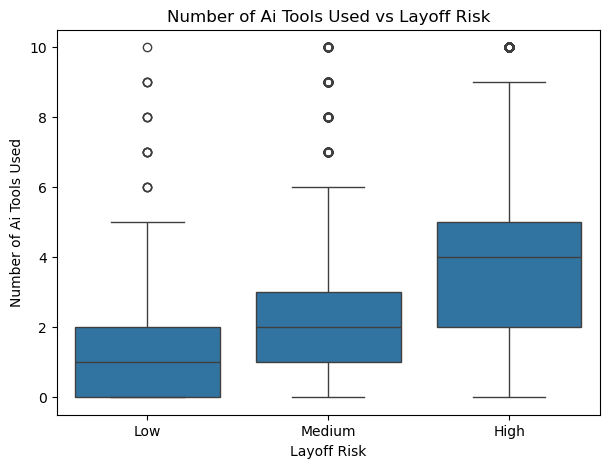

In [79]:
# Boxplot Analysis via layoff risk

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='layoff_risk', y='number_of_ai_tools_used', order=['Low', 'Medium', 'High'])
plt.title('Number of Ai Tools Used vs Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('Number of Ai Tools Used')
plt.show()

Observation:
- The average Number of AI Tools Used increases consistently across layoff risk categories: Low (1.25), Medium (2.27), and High (3.81).

- Employees using a greater number of AI tools are more likely to belong to higher layoff risk categories, whereas employees using fewer AI tools are predominantly classified as low risk. This suggests that greater reliance on AI tools is associated with increased exposure to AI-driven workforce changes.

#### Statistical Analysis

In [80]:
# ANOVA Test

low = df[df['layoff_risk'] == 'Low']['number_of_ai_tools_used']
medium = df[df['layoff_risk'] == 'Medium']['number_of_ai_tools_used']
high = df[df['layoff_risk'] == 'High']['number_of_ai_tools_used']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('The mean Number of AI Tools Used is the same across all Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean Number of AI Tools Used')

3388.99
0.0
We reject the null hypothesis
At least one Layoff Risk category has a different mean Number of AI Tools Used


Observation:
- The One-Way ANOVA revealed a statistically significant difference in the mean Number of AI Tools Used across the three Layoff Risk categories. Therefore, the null hypothesis is rejected, indicating that employees in at least one layoff risk category use a significantly different number of AI tools.

In [81]:
# Tukey HSD Test

tukey = pairwise_tukeyhsd(
    endog=df['number_of_ai_tools_used'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low   -2.559   0.0 -2.6324 -2.4856   True
  High Medium   -1.539   0.0 -1.6124 -1.4655   True
   Low Medium     1.02   0.0  0.9461   1.094   True
---------------------------------------------------


Observation:
- The Tukey HSD test confirmed that all pairwise comparisons were statistically significant.
- Employees in the High layoff risk category used significantly more AI tools than those in the Medium (mean difference = 1.54) and Low (mean difference = 2.56) layoff risk categories, while the Medium risk group also used significantly more AI tools than the Low risk group (mean difference = 1.02).

In [82]:
# Eta-Squared Test

# Overall Mean
grand_mean = df["number_of_ai_tools_used"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["number_of_ai_tools_used"].count() *
    (df.groupby("layoff_risk")["number_of_ai_tools_used"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["number_of_ai_tools_used"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.2531


Observation:
- The effect size (η² = 0.2531) indicates a large practical effect, suggesting that approximately 25.3% of the variation in the Number of AI Tools Used is associated with differences among the layoff risk groups.

Conclusion:
- The analysis confirms that the Number of AI Tools Used has a statistically significant and practically meaningful association with layoff risk. Although its effect is smaller than Routine Task Percentage and Creativity Requirement, it remains one of the strongest AI adoption indicators, highlighting that increased use of AI tools is closely associated with higher AI-related layoff risk.

### AI Usage Hours Per Week
- It measures how much time an employee actively uses AI technologies to complete their work.

#### Univariate Analysis of Ai Usage Hours per Week

In [83]:
# descriptive stats summary

summary_of_ai_usage = df['ai_usage_hours_per_week'].describe().round(2)
summary_of_ai_usage

count    20000.00
mean         6.77
std          6.09
min          0.00
25%          2.00
50%          5.00
75%         10.00
max         30.00
Name: ai_usage_hours_per_week, dtype: float64

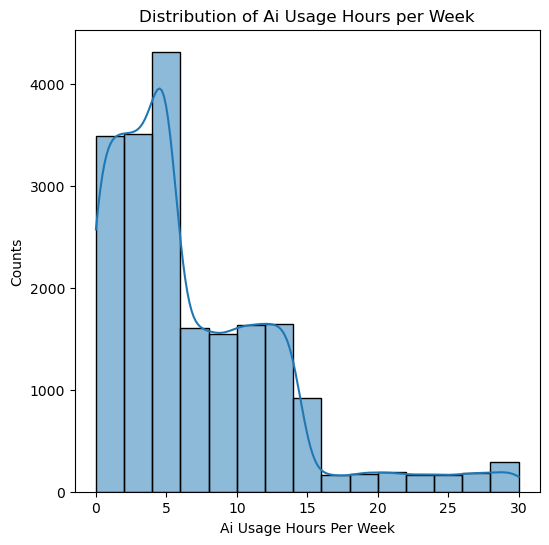

In [84]:
# Visualize the data via histplot

plt.figure(figsize=(6,6))
sns.histplot(data=df, x='ai_usage_hours_per_week', kde=True, bins=15)
plt.title('Distribution of Ai Usage Hours per Week')
plt.xlabel('Ai Usage Hours Per Week')
plt.ylabel('Counts')
plt.show()

Observation:
- AI Usage Hours Per Week ranges from 0 to 30 hours, with an average of 6.77 hours and a median of 5 hours. The distribution is positively skewed, indicating that most employees use AI for relatively few hours each week, while a smaller proportion use AI extensively.
- The dataset includes employees with both low and high levels of AI usage, although the majority spend relatively few hours using AI each week. This variation provides a suitable basis for evaluating whether greater AI usage is associated with AI-related layoff risk.

#### Bivariate Analysis: Ai Usage Hours per Week vs Latyoff Risk

In [85]:
# Group-wise descriptive stats analysis

layoff_ai_usage = df.groupby('layoff_risk')['ai_usage_hours_per_week'].describe().round(2)
display(layoff_ai_usage)

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,10.77,6.68,0.0,6.0,10.0,13.0,30.0
Low,6602.0,3.27,3.00,0.0,1.0,3.0,5.0,30.0
Medium,6601.0,6.16,5.31,0.0,2.0,5.0,9.0,30.0


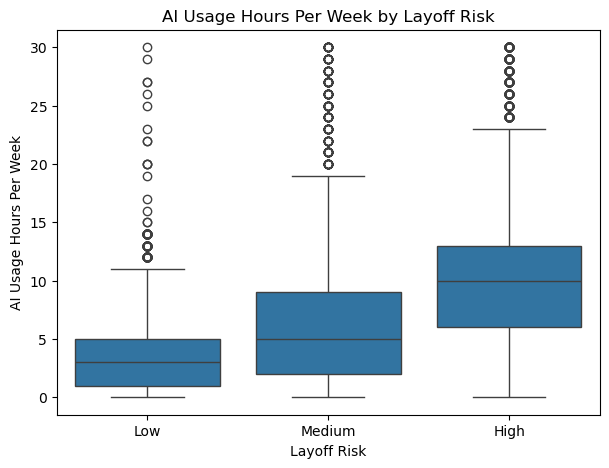

In [86]:
# boxplot

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='layoff_risk', y='ai_usage_hours_per_week', order=['Low', 'Medium', 'High'])
plt.title('AI Usage Hours Per Week by Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('AI Usage Hours Per Week')
plt.show()

Observation:
- The average AI Usage Hours Per Week increases consistently across layoff risk categories: Low (3.27 hours), Medium (6.16 hours), and High (10.77 hours). The median follows the same trend (3 --> 5 --> 10 hours), indicating that employees in higher layoff risk categories spend more time using AI each week. Although several high-value outliers are present, the three groups show a clear upward trend.
- Employees who spend more hours using AI each week are more likely to belong to higher layoff risk categories, whereas employees with lower AI usage are predominantly classified as low risk. This suggests that greater intensity of AI usage is associated with increased exposure to AI-driven workforce changes.

#### Statistical Analysis

In [87]:
# ANOVA Testlow = df[df['layoff_risk'] == 'Low']['ai_usage_hours_per_week']
medium = df[df['layoff_risk'] == 'Medium']['ai_usage_hours_per_week']
high = df[df['layoff_risk'] == 'High']['ai_usage_hours_per_week']


f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('The mean AI Usage Hours Per Week is the same across all Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean AI Usage Hours Per Week')

6078.88
0.0
We reject the null hypothesis
At least one Layoff Risk category has a different mean AI Usage Hours Per Week


Observation:
- The ANOVA results confirm that AI Usage Hours Per Week differs significantly across the Low, Medium, and High layoff risk categories. This indicates that the intensity of AI usage varies meaningfully among employees with different levels of layoff risk.

In [88]:
# Tukey HSD Test

tukey = pairwise_tukeyhsd(
    endog=df['ai_usage_hours_per_week'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -7.4949   0.0 -7.7071 -7.2827   True
  High Medium  -4.6044   0.0 -4.8166 -4.3922   True
   Low Medium   2.8905   0.0  2.6767  3.1043   True
---------------------------------------------------


Observation:
- The Tukey HSD test confirmed that all pairwise comparisons were statistically significant (adjusted p < 0.001). The largest difference in AI Usage Hours Per Week was observed between the High and Low layoff risk groups (7.49 hours), followed by High vs Medium (4.60 hours) and Medium vs Low (2.89 hours).
- Employees in the High layoff risk category spend significantly more time using AI each week than those in the Medium and Low risk categories. The consistent increase in AI usage hours across the three layoff risk groups suggests that greater AI usage intensity is associated with higher AI-related layoff risk.

In [89]:
# Eta Squared Test

# Overall Mean
grand_mean = df["ai_usage_hours_per_week"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["ai_usage_hours_per_week"].count() *
    (df.groupby("layoff_risk")["ai_usage_hours_per_week"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["ai_usage_hours_per_week"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.2589


Observation:
- The effect size (η² = 0.2589) indicates a large practical effect, suggesting that approximately 25.9% of the variation in AI Usage Hours Per Week is associated with differences among the layoff risk groups.
- The findings indicate that employees who spend more time using AI each week are significantly more likely to belong to higher layoff risk categories. The consistent increase in AI usage hours from the Low to High layoff risk groups suggests that greater reliance on AI technologies is strongly associated with increased workforce exposure to AI-driven automation.

Conclusion:
- The analysis confirms that AI Usage Hours Per Week has a statistically significant and practically meaningful association with layoff risk. Among the AI adoption variables analyzed so far, AI Usage Hours Per Week exhibits one of the strongest practical effects, indicating that the intensity of AI usage is closely associated with employees' AI-related layoff risk.

### Tasks Automated Percentage
- It measures what percentage of an employee's tasks are completed automatically by AI instead of manually.

#### Univariate Analysis of Tasks Automated Percentage

In [90]:
# descriptive Summary

summary_of_task_automated = df['tasks_automated_percentage'].describe().round(2)
summary_of_task_automated

count    20000.00
mean        37.23
std         20.00
min          4.00
25%         21.00
50%         35.00
75%         51.00
max         93.00
Name: tasks_automated_percentage, dtype: float64

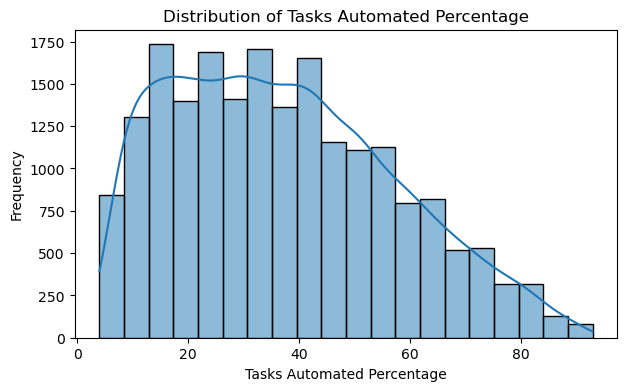

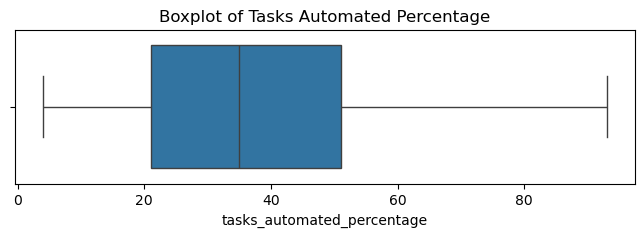

In [91]:
# histplot

plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tasks_automated_percentage', bins=20, kde=True)
plt.title("Distribution of Tasks Automated Percentage")
plt.xlabel("Tasks Automated Percentage")
plt.ylabel("Frequency")
plt.show()

# boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["tasks_automated_percentage"])
plt.title("Boxplot of Tasks Automated Percentage")
plt.show()

Observation:
- Tasks Automated Percentage ranges from 4% to 93%, with an average of 37.23%. The distribution is moderately right-skewed, indicating that while most employees have a low to moderate proportion of automated tasks, a smaller number have much higher automation levels.
- This variable is particularly important because it measures the direct impact of AI on an employee's work, not just AI exposure or usage. If our hypothesis is correct, we should expect employees with a higher percentage of automated tasks to have a higher layoff risk.

#### Bivariate Analysis: Task Automated percentage vs Layoff Risk

In [92]:
# Group-wise descriptive stats analysis

layoff_task_automated = df.groupby('layoff_risk')['tasks_automated_percentage'].describe().round(2)
layoff_task_automated

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,55.96,15.02,13.0,44.0,55.0,67.0,93.0
Low,6602.0,19.45,10.49,4.0,11.0,17.0,26.0,75.0
Medium,6601.0,35.72,13.76,5.0,26.0,34.0,44.0,92.0


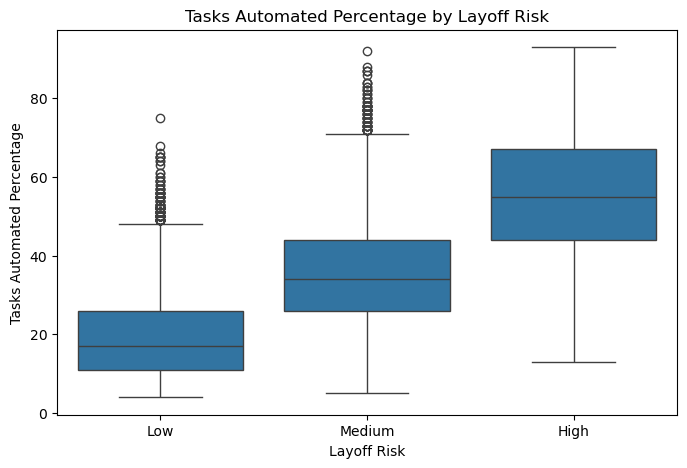

In [93]:
# Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='layoff_risk', y='tasks_automated_percentage', order=['Low', 'Medium', 'High'])
plt.title('Tasks Automated Percentage by Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('Tasks Automated Percentage')
plt.show()

Observation:
- The median Tasks Automated Percentage increases steadily across all three layoff risk groups:
    - Low: 17%
    - Medium: 34%
    - High: 55%
- The distributions show a clear upward shift with minimal overlap between the groups, particularly between the Low and High categories.
The High layoff risk group has the highest median and overall distribution, indicating substantially greater levels of task automation.
Some outliers are present in the Low and Medium groups, but they appear to be valid observations and do not warrant removal.

- Employees in the High layoff risk category have a much larger proportion of their work automated compared with employees in the Medium and Low risk categories. This suggests that as a greater share of an employee's responsibilities is automated, the likelihood of belonging to a higher layoff risk category also increases.

#### Statistical Analysis: Task Automated Percentage vs Layoff Risk

In [94]:
# ANOVA Test

low = df[df['layoff_risk'] == 'Low']['tasks_automated_percentage']
medium = df[df['layoff_risk'] == 'Medium']['tasks_automated_percentage']
high = df[df['layoff_risk'] == 'High']['tasks_automated_percentage']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('The mean task automated percentage is the same across all Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean task automated percentage')

12776.84
0.0
We reject the null hypothesis
At least one Layoff Risk category has a different mean task automated percentage


Observation:
- The ANOVA results confirm that the average Tasks Automated Percentage differs significantly among the Low, Medium, and High layoff risk groups (F = 12776.84, p < 0.001). This indicates that the proportion of work automated by AI varies substantially across employees with different levels of layoff risk.
- The findings suggest that employees with a higher proportion of automated tasks are significantly more likely to belong to higher layoff risk categories. This supports the business expectation that greater automation of job responsibilities is associated with increased exposure to AI-driven workforce changes.

In [95]:
# Tukey HSD Test

tukey = pairwise_tukeyhsd(
    endog=df['tasks_automated_percentage'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  High    Low -36.5061   0.0 -37.0427 -35.9695   True
  High Medium -20.2324   0.0 -20.7691 -19.6958   True
   Low Medium  16.2737   0.0  15.7331  16.8142   True
-----------------------------------------------------


Observation:
- The Tukey HSD test showed that all pairwise comparisons between the Low, Medium, and High layoff risk groups were statistically significant. The largest mean difference was observed between the High and Low layoff risk groups (36.51% points), followed by High vs Medium (20.23% points) and Medium vs Low (16.27% points). These results indicate that each layoff risk category has a distinct level of task automation.
- Employees in the High layoff risk category have a substantially larger proportion of their work automated than those in the Medium and Low risk categories. The consistent increase in task automation across the three groups suggests that the extent of work automated by AI is strongly associated with higher layoff risk. From a business perspective, employees whose responsibilities are increasingly automated may face greater workforce disruption as AI capabilities expand.

In [96]:
# Eta Squared Test

# Overall Mean
grand_mean = df["tasks_automated_percentage"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["tasks_automated_percentage"].count() *
    (df.groupby("layoff_risk")["tasks_automated_percentage"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["tasks_automated_percentage"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.5610


Observation:
- The large effect size (η² = 0.5610) indicates that task automation is one of the strongest variables associated with layoff risk in this dataset.
- The findings suggest that as a greater proportion of an employee's work becomes automated, the likelihood of belonging to a higher layoff risk category increases. Employees in the High layoff risk group have substantially more of their work automated than those in the Medium and Low risk groups, highlighting task automation as a key factor associated with AI-driven workforce changes.

Conclusion:
- Tasks Automated Percentage is one of the strongest predictors of layoff risk in this analysis. The combination of a highly significant ANOVA result, statistically significant differences between all layoff risk groups, and a very large effect size demonstrates that the extent to which AI automates an employee's work is strongly associated with AI-related layoff risk. Organizations should monitor roles with high levels of task automation, as these positions may require proactive reskilling, job redesign, or workforce planning initiatives.

### AI Training Hours
- AI Training Hours represent the total number of hours an employee has spent receiving formal AI-related training, such as workshops, online courses, certifications, or company training programs.

#### Univariate Analysis of Ai Training Hours

In [97]:
# descriptive stats analysis

summary_of_ai_training = df['ai_training_hours'].describe().round(2)
summary_of_ai_training

count    20000.00
mean        12.62
std         13.55
min          0.00
25%          4.00
50%          8.00
75%         18.00
max         79.00
Name: ai_training_hours, dtype: float64

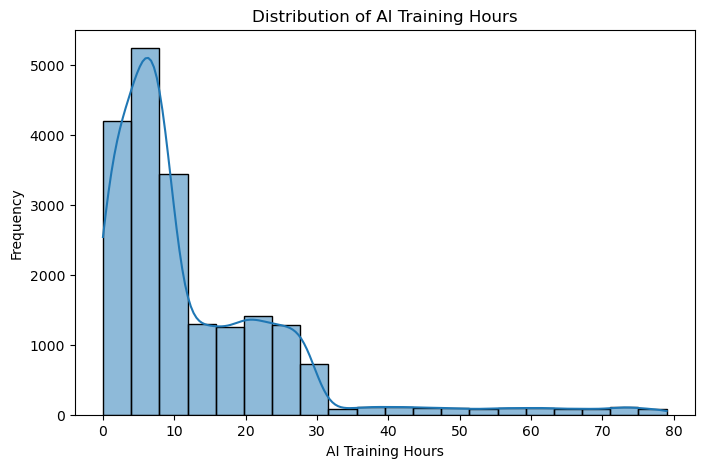

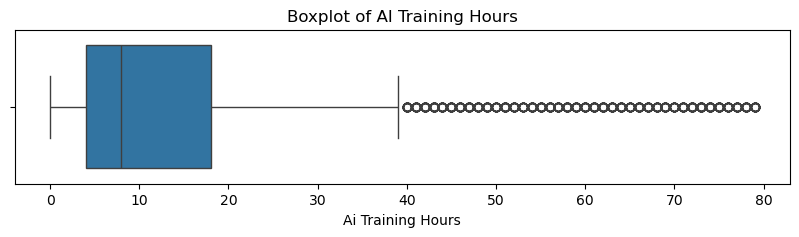

In [98]:
# histplot

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='ai_training_hours', bins=20, kde=True)
plt.title('Distribution of AI Training Hours')
plt.xlabel('AI Training Hours')
plt.ylabel('Frequency')
plt.show()

# boxplot

plt.figure(figsize=(10,2))
sns.boxplot(x=df['ai_training_hours'])
plt.title('Boxplot of AI Training Hours')
plt.xlabel('Ai Training Hours')
plt.show()

Observation:
- The distribution is positively (right) skewed.
- The mean (12.62 hours) is higher than the median (8 hours), confirming the right-skewed distribution.
- Most employees have low AI training hours, with the highest concentration between 0 and 10 hours.
- A smaller number of employees have much higher training hours, creating a long right tail.

Most employees have received relatively limited AI training, while a smaller group has invested substantially more time in AI learning. This suggests that AI training is not evenly distributed across the workforce.

#### Bivariate Analysis: Ai Training Hours vs Layoff Risk

In [99]:
# Grpup-wise Descriptive stats

layoff_ai_training = df.groupby('layoff_risk')['ai_training_hours'].describe().round(2)
layoff_ai_training

,count,mean,std,min,25%,50%,75%,max
layoff_risk,,,,,,,,
High,6797.0,20.24,16.41,0.0,8.0,17.0,26.0,79.0
Low,6602.0,5.97,6.00,0.0,2.0,5.0,8.0,78.0
Medium,6601.0,11.42,11.74,0.0,4.0,8.0,17.0,79.0


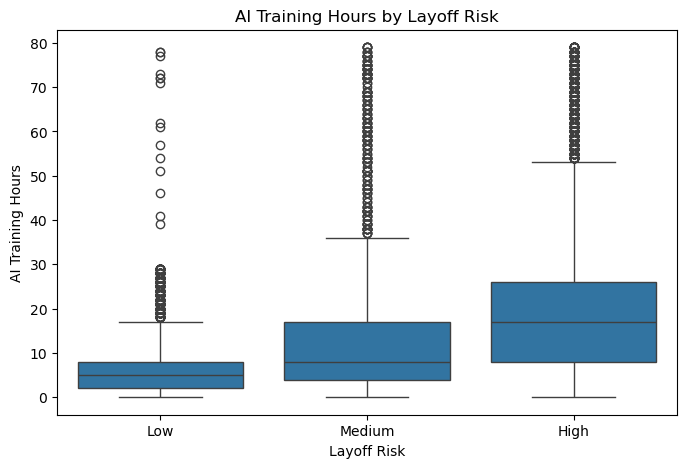

In [100]:
# Boxplot 

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='layoff_risk', y='ai_training_hours', order=['Low', 'Medium', 'High'])
plt.title('AI Training Hours by Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('AI Training Hours')
plt.show()

Observation:
- The median AI Training Hours increases steadily from Low --> Medium --> High.
- The entire distribution shifts upward as layoff risk increases.
- The High layoff risk group has the highest median and the widest spread, indicating greater variation in training hours.
- Outliers are present in all three groups, particularly in the Medium and High categories. These represent employees with exceptionally high AI training hours and are plausible observations rather than data errors.

Employees in the High layoff risk category have received substantially more AI training than employees in the Medium and Low risk categories. This suggests that organizations may be investing more heavily in AI training for employees whose roles are undergoing significant AI-driven transformation.

#### Statistical Analysis

In [101]:
# ANOVA Test

low = df[df['layoff_risk'] == 'Low']['ai_training_hours']
medium = df[df['layoff_risk'] == 'Medium']['ai_training_hours']
high = df[df['layoff_risk'] == 'High']['ai_training_hours']

f_test, p_value = f_oneway(low, medium, high)
print(f_test.round(2))
print(p_value)

alpha=0.05

if p_value > alpha:
    print('We fail to reject the null hypothesis')
    print('The mean AI Training Hours is the same across all Layoff Risk categories')
else:
    print('We reject the null hypothesis')
    print('At least one Layoff Risk category has a different mean AI Training Hours')

2339.51
0.0
We reject the null hypothesis
At least one Layoff Risk category has a different mean AI Training Hours


Observation:
- The ANOVA results confirm that AI Training Hours differ significantly among the Low, Medium, and High layoff risk groups. This indicates that the amount of AI training received varies meaningfully across employees with different levels of layoff risk.

- The findings suggest that AI Training Hours are associated with layoff risk. Employees in different layoff risk categories receive significantly different amounts of AI training. Based on the group means observed earlier (Low: 5.97 hours, Medium: 11.42 hours, High: 20.24 hours), employees in the High layoff risk group have received the most AI training. This pattern may indicate that organizations are investing more heavily in training employees whose roles are undergoing substantial AI-driven transformation. However, this analysis demonstrates an association, not a cause-and-effect relationship.

In [102]:
# Tukey HSD Test

tukey = pairwise_tukeyhsd(
    endog=df['ai_training_hours'],
    groups=df['layoff_risk'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper  reject
----------------------------------------------------
  High    Low -14.2742   0.0 -14.7684  -13.78   True
  High Medium  -8.8218   0.0   -9.316 -8.3277   True
   Low Medium   5.4524   0.0   4.9546  5.9501   True
----------------------------------------------------


Observation:
- The Tukey HSD test confirmed that all pairwise comparisons between the Low, Medium, and High layoff risk groups were statistically significant. The largest mean difference was observed between the High and Low layoff risk groups (14.27 hours), followed by High vs Medium (8.82 hours) and Medium vs Low (5.45 hours). These findings indicate that each layoff risk category has a distinct average level of AI training.

- Employees in the High layoff risk category have received significantly more AI training than those in the Medium and Low risk categories. This suggests that organizations may be providing additional AI training to employees working in roles experiencing greater AI adoption and automation. However, these results indicate an association rather than a causal relationship. It should not be concluded that AI training increases layoff risk; instead, AI training and layoff risk may both be influenced by the degree of AI transformation within specific roles.

In [103]:
# Eta Squared Test

# Overall Mean
grand_mean = df["ai_training_hours"].mean()

# Sum of Squares Between Groups
ss_between = sum(
    df.groupby("layoff_risk")["ai_training_hours"].count() *
    (df.groupby("layoff_risk")["ai_training_hours"].mean() - grand_mean) ** 2)

# Total Sum of Squares
ss_total = sum((df["ai_training_hours"] - grand_mean) ** 2)

# Eta Squared
eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.4f}")

Eta Squared: 0.1896


Observation:
- The effect size (η² = 0.1896) indicates a large practical effect, suggesting that approximately 19.0% of the variation in AI Training Hours is associated with differences among the layoff risk groups.
- Employees in the High layoff risk category receive substantially more AI training than employees in the Medium and Low risk categories. This likely reflects organizational efforts to prepare employees in AI-intensive or rapidly changing roles. However, this analysis identifies an association rather than causation. It should not be interpreted as evidence that AI training increases layoff risk; instead, employees in roles undergoing greater AI transformation may both receive more training and face higher layoff risk.

Conclusion:
- AI Training Hours is significantly associated with layoff risk and exhibits a large practical effect. While it is not among the strongest predictors in the dataset, the findings suggest that organizations tend to invest more in AI training for employees working in roles with greater AI exposure. AI training should therefore be viewed as an indicator of organizational AI transformation rather than a direct driver of layoff risk.

## Quick Analyze the whole data after analyzing

In [104]:
effect_size_df = pd.DataFrame({
    "Rank": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],

    "Variable":[
        "Routine Task Percentage",
        "Creativity Requirement",
        "Tasks Automated Percentage",
        "AI Adoption Level",
        "AI Usage Hours Per Week",
        "Number of AI Tools Used",
        "Human Interaction Level",
        "Job Level",
        "AI Training Hours",
        "Job Role",
        "Industry",
        "Education Level",
        "Years of Experience",
        "Age",
        "Company Size"
    ],

    "Statistical Test":[
        "ANOVA",
        "ANOVA",
        "ANOVA",
        "Chi-Square",
        "ANOVA",
        "ANOVA",
        "ANOVA",
        "Chi-Square",
        "ANOVA",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "ANOVA",
        "ANOVA",
        "Chi-Square"
    ],

    "Effect Size": [
        "61.01%",
        "56.85%",
        "56.10%",
        "44.54%",
        "25.89%",
        "25.31%",
        "25.26%",
        "20.27%",
        "18.96%",
        "17.57%",
        "16.98%",
        "12.24%",
        "1.01%",
        "0.14%",
        "-"
    ],

    "Metric":[
        "Eta Squared",
        "Eta Squared",
        "Eta Squared",
        "Cramer's V",
        "Eta Squared",
        "Eta Squared",
        "Eta Squared",
        "Cramer's V",
        "Eta Squared",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Eta Squared",
        "Eta Squared",
        "-"
    ],

    "Interpretation":[
        "Very Large",
        "Very Large",
        "Very Large",
        "Strong",
        "Large",
        "Large",
        "Large",
        "Large",
        "Large",
        "Weak",
        "Weak",
        "Weak",
        "Small",
        "Negligible",
        "No Association"
    ]
})

display(effect_size_df.style.hide(axis='index'))

Rank,Variable,Statistical Test,Effect Size,Metric,Interpretation
1,Routine Task Percentage,ANOVA,61.01%,Eta Squared,Very Large
2,Creativity Requirement,ANOVA,56.85%,Eta Squared,Very Large
3,Tasks Automated Percentage,ANOVA,56.10%,Eta Squared,Very Large
4,AI Adoption Level,Chi-Square,44.54%,Cramer's V,Strong
5,AI Usage Hours Per Week,ANOVA,25.89%,Eta Squared,Large
6,Number of AI Tools Used,ANOVA,25.31%,Eta Squared,Large
7,Human Interaction Level,ANOVA,25.26%,Eta Squared,Large
8,Job Level,Chi-Square,20.27%,Cramer's V,Large
9,AI Training Hours,ANOVA,18.96%,Eta Squared,Large
10,Job Role,Chi-Square,17.57%,Cramer's V,Weak


### Multivariate Analysis for Numerical Variables

#### Correlation Matrix

In [105]:
# First create the DataFrame with only the numerical variables

numerical_df = df.select_dtypes(include=["int64", "float64"])

# create a correlation matrix which is only this numerical variables

correlation_matrix = numerical_df.corr(numeric_only=True).round(2)
correlation_matrix

,age,years_of_experience,routine_task_percentage,creativity_requirement,human_interaction_level,number_of_ai_tools_used,ai_usage_hours_per_week,tasks_automated_percentage,ai_training_hours
age,1.00,0.38,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
years_of_experience,0.38,1.00,-0.00,0.00,0.01,-0.00,-0.00,-0.00,-0.00
routine_task_percentage,0.00,-0.00,1.00,-0.93,-0.02,0.66,0.67,0.89,0.60
creativity_requirement,0.00,0.00,-0.93,1.00,0.02,-0.62,-0.63,-0.83,-0.56
human_interaction_level,0.00,0.01,-0.02,0.02,1.00,-0.01,-0.01,-0.01,-0.01
number_of_ai_tools_used,0.00,-0.00,0.66,-0.62,-0.01,1.00,0.79,0.59,0.74
ai_usage_hours_per_week,0.00,-0.00,0.67,-0.63,-0.01,0.79,1.00,0.60,0.78
tasks_automated_percentage,-0.00,-0.00,0.89,-0.83,-0.01,0.59,0.60,1.00,0.53
ai_training_hours,-0.00,-0.00,0.60,-0.56,-0.01,0.74,0.78,0.53,1.00


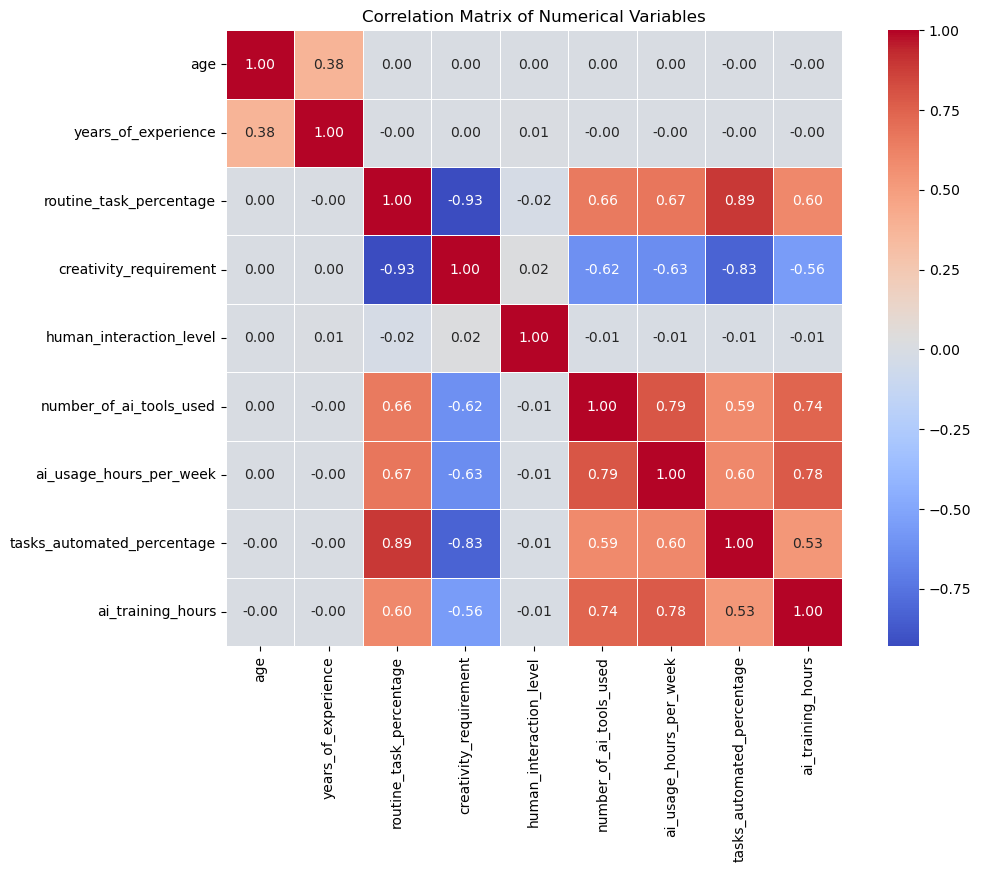

In [106]:
# create correlation heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Observation:
- The correlation analysis revealed several strong relationships among the numerical variables.
    - Routine Task Percentage showed a very strong positive correlation with Tasks Automated Percentage (r = 0.89) and a very strong negative correlation with Creativity Requirement (r = -0.93).
    - AI Usage Hours Per Week was strongly correlated with Number of AI Tools Used (r = 0.79) and AI Training Hours (r = 0.78).
    - Age, Years of Experience, and Human Interaction Level exhibited weak or negligible correlations with most other variables.

Business Summary:
- The heatmap suggests that routine, less creative jobs are more likely to undergo AI-driven automation. Employees working in AI-intensive environments tend to use more AI tools, spend more time using AI, and receive more AI training. In contrast, demographic characteristics such as age and years of experience appear to have relatively little relationship with AI adoption and automation measures.

#### Multicollinearity Analysis (VIF) - Variance Inflation Factor
- For Ex.--> If Routine Task % already explains most of the information, then Tasks Automated % may not contribute much additional information. This is called multicollinearity.
- VIF measures how much one predictor can be explained by the other predictors.

In [107]:
# import library for thhis analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# create feature df
x = df[[
    'age',
    'years_of_experience',
    'routine_task_percentage',
    'creativity_requirement',
    'human_interaction_level',
    'number_of_ai_tools_used',
    'ai_usage_hours_per_week',
    'tasks_automated_percentage',
    'ai_training_hours'
]]


# calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = x.columns
vif_df["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif_df["VIF"] = vif_df["VIF"].round(2)
vif_df

,Feature,VIF
0,age,14.32
1,years_of_experience,3.94
2,routine_task_percentage,32.52
3,creativity_requirement,6.18
4,human_interaction_level,7.81
5,number_of_ai_tools_used,7.49
6,ai_usage_hours_per_week,8.26
7,tasks_automated_percentage,21.52
8,ai_training_hours,5.33


Observation:
- The VIF analysis indicates the presence of multicollinearity among several predictor variables.
    - Routine Task Percentage (VIF = 32.52) and Tasks Automated Percentage (VIF = 21.52) exhibited very high VIF values, suggesting substantial overlap with other predictors.
    - AI Usage Hours Per Week, Human Interaction Level, Number of AI Tools Used, Creativity Requirement, and AI Training Hours also showed moderate to high VIF values, whereas Years of Experience demonstrated comparatively low multicollinearity (VIF = 3.94).

The results suggest that several AI-related variables describe interconnected aspects of employee work. For example, employees performing highly routine work also tend to have a greater proportion of automated tasks, spend more time using AI, and work in less creative roles. This indicates that AI adoption, task automation, and job characteristics are closely linked rather than independent business processes.

### Multivariate Analysis for Categorical Variables

#### Cramér's V Association Matrix

In [108]:
# create a Cramer's V Function

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]

    n = contingency_table.sum().sum()

    phi2 = chi2 / n

    r, k = contingency_table.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))

In [109]:
# Calculate the Associate Matrix

categorical_cols = [
    'education_level',
    'industry',
    'job_role',
    'company_size',
    'job_level',
    'ai_adoption_level'
]

cramers_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

cramers_matrix.round(3)

,education_level,industry,job_role,company_size,job_level,ai_adoption_level
education_level,1.000,0.018,0.029,0.017,0.007,0.007
industry,0.018,1.000,1.000,0.024,0.022,0.021
job_role,0.029,1.000,1.000,0.037,0.036,0.035
company_size,0.017,0.024,0.037,1.000,0.008,0.015
job_level,0.007,0.022,0.036,0.008,1.000,0.011
ai_adoption_level,0.007,0.021,0.035,0.015,0.011,1.000


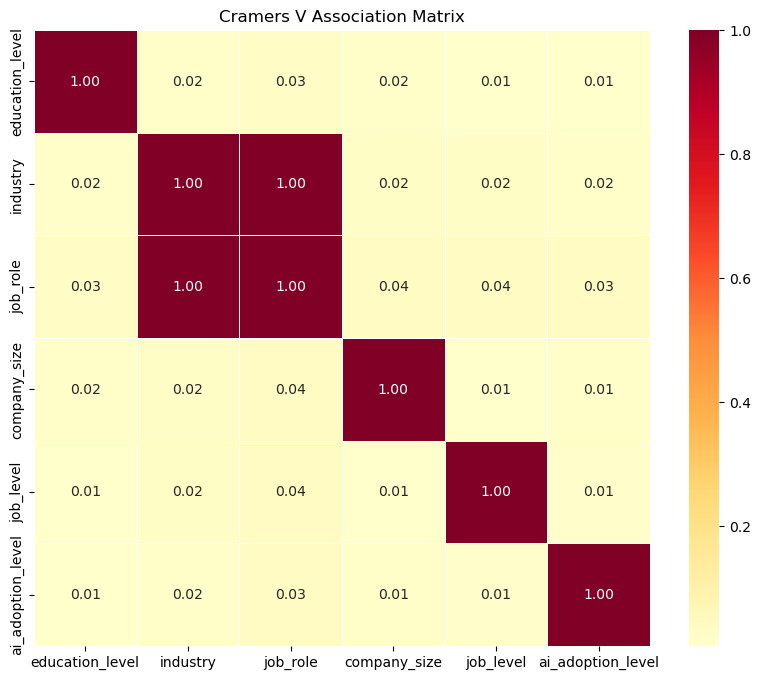

In [110]:
# heatmap

plt.figure(figsize=(10,8))
sns.heatmap(cramers_matrix, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=0.5, square=True)
plt.title('Cramers V Association Matrix')
plt.show()

# Final Key Findings:

### 1. The dataset was clean and reliable for analysis.
- Before starting the analysis, the dataset was checked for missing values, duplicate records, incorrect data types, and inconsistent values. Since no major data quality issues were found after preprocessing, the analysis can be considered reliable and trustworthy.

### 2. The dataset covers a wide variety of employees and organizations.
- The data includes employees from different industries, education levels, company sizes, job levels, and AI adoption levels. This helped us understand how AI impacts different types of jobs instead of focusing on only one industry or employee group.

### 3. Employees performing more routine work face the highest layoff risk.
- Among all the factors analyzed, Routine Task Percentage had the strongest relationship with layoff risk. Employees whose work mainly consists of repetitive and rule-based tasks are much more likely to be affected by AI and automation.

### 4. Jobs with a higher percentage of automated tasks are more likely to be at risk.
- As more tasks in a job become automated, the risk of layoffs also increases. This suggests that automation is replacing specific tasks, making some roles more vulnerable than others.

### 5. Creative jobs are less likely to be affected by AI.
- Employees whose work requires creativity, problem-solving, and decision-making generally showed a lower layoff risk. This indicates that AI still struggles to replace jobs that rely on human creativity and innovation.

### 6. Jobs that require more human interaction appear to be safer.
- Roles involving communication, teamwork, customer interaction, or relationship management showed a lower layoff risk compared to highly repetitive jobs. Human skills continue to play an important role even in AI-driven workplaces.

### 7. Companies with higher AI adoption tend to have higher layoff risk.
- Organizations that have adopted AI more extensively also showed a higher proportion of employees in medium and high layoff risk categories. This suggests that as AI adoption increases, workforce roles and responsibilities are also changing.

### 8. Employees at higher layoff risk are also the ones using AI more frequently.
- Employees in the high-risk group generally use more AI tools, spend more time working with AI, receive more AI training, and have more of their work automated. This shows that greater AI usage often goes hand in hand with greater workforce transformation.

### 9. The results are backed by statistical analysis, not just visual observations.
- The statistical tests confirmed that the relationships found during the analysis are unlikely to have occurred by chance. The effect size analysis also showed that several factors have a meaningful business impact, making the findings reliable for decision-making.

### 10. Many AI-related factors are closely connected with each other.
- The correlation analysis showed that employees performing routine work also tend to have more automated tasks, use AI more often, and receive more AI training. These factors work together rather than independently when influencing layoff risk.

### 11. Some AI-related variables provide similar information.
- The VIF analysis showed that variables like Routine Task Percentage and Tasks Automated Percentage are highly related. This means they describe similar aspects of a job, which is important to consider while building a machine learning model.

### 12. Most employee and company characteristics are independent of each other.
- The Cramér's V analysis showed that most categorical variables, such as Education Level, Company Size, and Job Level, are not strongly related to one another. The only strong relationship was between Industry and Job Role, which appears to be a characteristic of the dataset's structure rather than a typical real-world business pattern.

### 13. Overall, the nature of the job matters more than the employee's background.
- The analysis shows that what an employee does every day has a much bigger impact on layoff risk than who the employee is. Factors like routine work, automation, creativity, and AI adoption are much stronger indicators of layoff risk than age, education, or years of experience.

# Business Recommendations

### 1. Use AI to improve work, not just reduce headcount.
Companies should focus on using AI to automate repetitive tasks while allowing employees to spend more time on creative, analytical, and customer-focused work. This creates value for both the business and its workforce.

### 2. Make continuous learning a shared responsibility.
Employees should actively develop AI and digital skills, while organizations should provide learning opportunities that help people adapt to changing job requirements. In the AI era, continuous learning benefits everyone.

### 3. Redesign jobs as AI capabilities grow.
Instead of replacing entire roles, businesses should redesign jobs by combining AI with human expertise. Employees can focus on work that requires judgment, collaboration, and innovation, while AI handles repetitive activities.

### 4. Invest in skills that AI cannot easily replace.
Organizations should encourage the development of creativity, critical thinking, communication, leadership, and problem-solving. Employees who strengthen these skills will remain valuable even as automation increases.

### 5. Introduce AI with a clear workforce transition plan.
Before implementing AI at scale, companies should identify which roles will change, what new skills will be required, and how affected employees can move into future-ready roles. Planning ahead reduces uncertainty and builds trust.

### 6. Use data to guide workforce decisions.
Businesses should regularly monitor automation levels, changing skill requirements, and workforce trends instead of making reactive decisions. Data-driven planning helps organizations prepare for change before challenges become business problems.

### 7. Encourage employees to work alongside AI.
Employees should view AI as a productivity partner rather than a competitor. Learning how to use AI effectively can improve individual performance, increase career opportunities, and help employees stay relevant in a rapidly evolving workplace.

### 8. Build a future-ready organization where technology and people grow together.
Long-term success will come from balancing AI adoption with employee development. Organizations that invest in both technology and their people are more likely to improve productivity, retain talent, and remain competitive in the evolving world of work.

# Limitations of this Project

- This analysis identifies relationships between variables but does not establish cause-and-effect. 
- The findings are based on the available dataset and may not capture all factors that influence layoff risk, such as company policies, economic conditions, or employee performance.
- The relationship between Industry and Job Role reflects the structure of the dataset and may not fully represent real-world workforce distributions.

# EDA Conclusion

The Exploratory Data Analysis (EDA) provided a comprehensive understanding of the factors associated with AI adoption and employee layoff risk across different industries and job roles. The analysis revealed that the nature of an employee's work has a greater influence on layoff risk than the employee's background. Employees performing highly routine and automatable tasks were more likely to face higher layoff risk, while roles requiring creativity, critical thinking, and human interaction appeared to be more resilient in an AI-driven workplace.

The analysis also showed that AI adoption is transforming how work is performed rather than affecting all jobs equally. Organizations with greater AI adoption are experiencing changes in workforce responsibilities, highlighting the need to balance technological advancement with employee development. These findings suggest that successful AI implementation should focus not only on improving operational efficiency but also on preparing employees for evolving job requirements through continuous learning, reskilling, and job redesign.

From a business perspective, the study emphasizes that workforce planning should be driven by data rather than assumptions. Understanding which roles are most affected by automation enables organizations to make more informed decisions about AI adoption, talent development, and future workforce strategies while minimizing unnecessary disruption.

Overall, this EDA establishes a strong analytical foundation for the next phase of the project. The insights gained from the analysis will be used to develop and evaluate machine learning models capable of predicting employee layoff risk, helping organizations identify high-risk roles early and support more proactive, data-driven workforce planning.